In [388]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [389]:
# matplotlib 한글 깨짐 방지
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action="ignore")

plt.rc("font", family="AppleGothic")

In [390]:
# 데이터 받아오기 및 차원 확인
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print("train:", train_df.shape, "| test:", test_df.shape)
train_df.head()

train: (891, 12) | test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [391]:
def get_nullcnt_ratio_describe(df: pd.DataFrame) -> pd.DataFrame:
    """주어진 DataFrame 객체에서 결측치가 존재하는 컬럼의 이름과 그 개수, 비율, 그리고 정보를 담은 DataFrame을 리턴합니다."""
    # 각 컬럼별 결측치 개수 계산
    null_counts = df.isnull().sum()
    
    # 결측치가 1개 이상 존재하는 컬럼만 필터링
    null_counts = null_counts[null_counts > 0]
    
    # 결측치 비율 계산 (결측치 개수 / 전체 행 개수)
    null_ratios = null_counts / len(df)

    # 결측치 행의 정보 확인
    null_infos = df[null_counts.index].describe(include='all').transpose()
    
    # 데이터프레임으로 변환
    null_df = pd.DataFrame({
        'Null_Count': null_counts,
        'Null_Ratio': null_ratios,
    })
    null_df = pd.concat([null_df, null_infos], axis=1)
    
    # 결측치 개수를 기준으로 내림차순 정렬하여 반환
    return null_df.sort_values(by='Null_Count', ascending=False)

In [392]:
from matplotlib.ticker import PercentFormatter


def plot_category_counts(
    df: pd.DataFrame,
    column: str,
    *,
    name: str | None = None,
    sort_by_count: bool = True,
    show_ratio: bool = True,
    normalize: bool = False,
    order: list | None = None,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """범주형 컬럼의 도수를 막대그래프로 그리고, 그린 Axes를 리턴합니다.

    Args:
        df: 대상 DataFrame.
        column: 도수를 셀 범주형 컬럼명.
        name: 제목 앞에 붙일 데이터셋 이름(예: "train_df"). None이면 생략합니다.
        sort_by_count: True면 도수 내림차순, False면 원래 범주 순서로 정렬합니다.
        show_ratio: True면 막대 위 라벨에 비율(%)을 함께 표시합니다.
        normalize: True면 y축을 도수 대신 비율로 그립니다. 행 수가 다른 데이터셋끼리
            비교할 때 사용합니다.
        order: 사용할 범주 순서. 주어지면 sort_by_count보다 우선하며, 해당 범주가
            없으면 0으로 표시합니다. 여러 데이터셋의 막대 순서를 맞출 때 사용합니다.
        ax: 그릴 Axes. None이면 새로 생성합니다.
    """
    # 도수 계산 (결측치도 하나의 범주로 함께 확인)
    counts = df[column].value_counts(dropna=False)
    total = int(counts.sum())

    # 범주 순서 결정 (order가 있으면 그 순서를 그대로 따름)
    if order is not None:
        counts = counts.reindex(order, fill_value=0)
    elif sort_by_count:
        counts = counts.sort_values(ascending=False)
    else:
        counts = counts.sort_index()

    # x축 라벨 생성 (결측치는 명시적으로 표기)
    labels = ["결측(NaN)" if pd.isna(idx) else str(idx) for idx in counts.index]

    # y축에 그릴 높이: normalize면 비율, 아니면 도수 그대로
    values = counts.to_numpy()
    heights = values / total if normalize else values

    # Axes 준비 (외부에서 받은 게 없으면 새로 생성)
    if ax is None:
        _, ax = plt.subplots(figsize=(max(4, len(counts) * 1.2), 4))

    # 단일 계열이므로 색은 하나만 사용
    bars = ax.bar(labels, heights, color="#2a78d6", width=0.6, zorder=2)

    # 막대 위에 도수(및 비율) 라벨 표시
    for bar, value in zip(bars, values):
        text = f"{value:,}\n({value / total:.1%})" if show_ratio else f"{value:,}"
        ax.annotate(
            text,
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#52514e",
        )

    # 축과 그리드는 데이터보다 눈에 덜 띄게 처리
    title = f"{column} 분포 (n={total:,})"
    ax.set_title(f"{name} · {title}" if name else title, fontsize=12, color="#0b0b0b")
    ax.set_ylabel("비율" if normalize else "도수", fontsize=10, color="#52514e")
    ax.set_ylim(0, heights.max() * 1.18)
    if normalize:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.grid(axis="y", color="#e5e5e2", linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#c9c9c4")
    ax.tick_params(colors="#52514e", length=0)

    return ax


def compare_category_counts(
    dfs: dict[str, pd.DataFrame],
    column: str,
    *,
    sort_by_count: bool = True,
    show_ratio: bool = True,
    normalize: bool = True,
    figsize: tuple[float, float] | None = None,
) -> np.ndarray:
    """여러 DataFrame의 같은 범주형 컬럼 분포를 나란히 그려 비교하고, Axes 배열을 리턴합니다.

    막대 순서와 y축 범위를 모든 그래프에서 통일하므로 막대 높이를 직접 비교할 수 있습니다.

    Args:
        dfs: {데이터셋 이름: DataFrame} 형태의 딕셔너리. 키가 각 그래프 제목이 됩니다.
        column: 비교할 범주형 컬럼명.
        sort_by_count: True면 전체 합산 도수 내림차순, False면 범주 순서로 정렬합니다.
        show_ratio: True면 막대 위 라벨에 비율(%)을 함께 표시합니다.
        normalize: True면 y축을 비율로 그립니다. 행 수가 다른 데이터셋 비교의 기본값입니다.
        figsize: 전체 Figure 크기. None이면 범주 수와 데이터셋 수에 맞춰 자동 계산합니다.
    """
    # 모든 데이터셋의 범주를 합쳐 공통 순서를 만든다
    # (한쪽에만 있는 범주도 0으로 그려져야 비교가 정확함)
    merged_counts = pd.concat([df[column] for df in dfs.values()], ignore_index=True).value_counts(dropna=False)
    merged_counts = merged_counts.sort_values(ascending=False) if sort_by_count else merged_counts.sort_index()
    order = list(merged_counts.index)

    # 데이터셋 개수만큼 가로로 서브플롯 생성
    if figsize is None:
        figsize = (max(4.0, len(order) * 1.2) * len(dfs), 4.0)
    fig, axes = plt.subplots(1, len(dfs), figsize=figsize)
    axes = np.atleast_1d(axes)

    for ax, (name, df) in zip(axes, dfs.items()):
        plot_category_counts(
            df,
            column,
            name=name,
            show_ratio=show_ratio,
            normalize=normalize,
            order=order,
            ax=ax,
        )

    # y축 범위를 가장 큰 값에 맞춰 통일 (막대 높이를 직접 비교할 수 있도록)
    top = max(ax.get_ylim()[1] for ax in axes)
    for ax in axes:
        ax.set_ylim(0, top)

    fig.tight_layout()
    return axes

In [393]:
# 계열별 색 (첫 번째는 채운 막대, 나머지는 계단선으로 겹쳐 그림)
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]


def compute_bin_edges(values: np.ndarray, max_bins: int = 50) -> tuple[np.ndarray, str]:
    """연속형 값의 히스토그램 계급 경계와, 사용한 규칙 이름을 함께 리턴합니다.

    데이터 성격에 따라 규칙을 나눕니다.
      1. 정수형이고 값의 범위가 좁으면(25 이하) 폭 1의 정수 구간을 씁니다.
         이산 계수 데이터는 각 정수가 곧 하나의 값이라, 더 잘게 쪼개면 빈 구간이
         생기고 뭉치면 서로 다른 값이 섞입니다. (예: SibSp, Parch)
      2. 그 외에는 Freedman-Diaconis 규칙(h = 2*IQR/n^(1/3))을 씁니다.
         적분 평균제곱오차를 최소화하며, IQR 기반이라 이상치에 강건합니다.
      3. IQR이 0이면 FD 공식이 0으로 나누기가 되므로 Sturges 규칙으로 폴백합니다.
      4. 구간 수가 max_bins를 넘으면 상한을 적용합니다. 꼬리가 긴 분포에서
         FD가 요구하는 구간 수가 표본 대비 지나치게 많아지는 걸 막습니다. (예: Fare)

    Args:
        values: 결측치가 제거된 1차원 값 배열.
        max_bins: 허용할 최대 구간 수.
    """
    v = np.asarray(values, dtype=float)
    lo, hi = v.min(), v.max()

    # 모든 값이 같으면 구간을 나눌 수 없으므로 폭 1짜리 구간 하나만 만든다
    if hi <= lo:
        return np.array([lo - 0.5, lo + 0.5]), "단일값"

    # 1. 정수형 이산 데이터: 경계를 -0.5에 맞춰 각 정수가 구간 중앙에 오게 한다
    if np.all(v == np.round(v)) and (hi - lo + 1) <= 25:
        return np.arange(lo - 0.5, hi + 1.5, 1.0), "정수 구간"

    # 2. Freedman-Diaconis 규칙
    q1, q3 = np.percentile(v, [25, 75])
    width = 2 * (q3 - q1) / len(v) ** (1 / 3)

    if width > 0:
        n_bins, rule = int(np.ceil((hi - lo) / width)), "Freedman-Diaconis"
    else:
        # 3. IQR = 0 -> FD 계산 불가, Sturges로 폴백
        n_bins, rule = int(np.ceil(np.log2(len(v))) + 1), "Sturges"

    # 4. 구간 수 상한 적용
    if n_bins > max_bins:
        n_bins, rule = max_bins, f"{rule}, {max_bins}구간 상한"

    return np.linspace(lo, hi, n_bins + 1), rule


def compare_histograms(
    dfs: dict[str, pd.DataFrame],
    column: str,
    *,
    normalize: bool = True,
    max_bins: int = 50,
    clip_quantile: float | None = None,
    show_counts: bool | None = None,
    max_labels: int = 25,
    ax: plt.Axes | None = None,
    figsize: tuple[float, float] = (9.0, 4.5),
) -> plt.Axes:
    """여러 DataFrame의 같은 연속형 컬럼 분포를 한 축에 겹쳐 그리고, 그린 Axes를 리턴합니다.

    모든 데이터셋을 합친 값으로 계급 경계를 한 번만 계산하므로 막대가 정확히 정렬됩니다.
    계급 구간 규칙은 compute_bin_edges를 참고하세요.

    Args:
        dfs: {데이터셋 이름: DataFrame} 형태의 딕셔너리. 첫 번째가 채운 막대, 나머지는 계단선.
        column: 비교할 연속형 컬럼명.
        normalize: True면 y축을 각 데이터셋 내 비율로 그립니다. 행 수가 다른 데이터셋
            비교의 기본값입니다. False면 도수 그대로 그립니다.
        max_bins: 허용할 최대 구간 수.
        clip_quantile: 0~1 사이 분위수. 주어지면 그 위쪽 꼬리를 잘라내고 그립니다.
            Fare처럼 극단적인 이상치가 있어 분포 형태가 안 보일 때 0.99 등을 넘깁니다.
        show_counts: 막대 위에 계급별 도수를 표시할지 여부. None이면 계급 수가
            max_labels 이하일 때만 표시합니다. 계급이 많으면 라벨끼리 겹쳐
            읽을 수 없기 때문입니다.
        max_labels: show_counts가 None일 때 라벨을 붙일 최대 계급 수.
        ax: 그릴 Axes. None이면 새로 생성합니다.
        figsize: ax를 새로 만들 때 쓸 Figure 크기.
    """
    # 데이터셋별로 결측치를 제거하고, 몇 건이 빠졌는지 기록해 둔다
    series = {name: df[column].dropna().to_numpy(dtype=float) for name, df in dfs.items()}
    dropped = {name: int(df[column].isna().sum()) for name, df in dfs.items()}

    notes = []

    # 꼬리 잘라내기 (기준값은 전체를 합쳐서 한 번만 계산해 데이터셋 간 기준을 통일)
    if clip_quantile is not None:
        upper = np.quantile(np.concatenate(list(series.values())), clip_quantile)
        clipped = sum(int((v > upper).sum()) for v in series.values())
        series = {name: v[v <= upper] for name, v in series.items()}
        notes.append(f"상위 {(1 - clip_quantile):.0%} {clipped}건 제외(> {upper:,.4g})")

    # 전체를 합친 값으로 계급 경계를 한 번만 계산 -> 모든 계열의 막대가 정렬된다
    edges, rule = compute_bin_edges(np.concatenate(list(series.values())), max_bins=max_bins)

    # Axes 준비 (외부에서 받은 게 없으면 새로 생성)
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    heights = {}
    for i, (name, values) in enumerate(series.items()):
        color = SERIES_COLORS[i % len(SERIES_COLORS)]
        # normalize면 각 데이터셋 내 비율이 되도록 가중치를 준다
        weights = np.full(len(values), 1 / len(values)) if normalize else None
        label = f"{name} (n={len(values):,})"

        if i == 0:
            # 첫 계열은 채운 막대 (막대 사이 얇은 흰 경계로 구간을 구분)
            heights[name] = ax.hist(values, bins=edges, weights=weights, color=color, label=label,
                                    edgecolor="white", linewidth=0.5, zorder=2)[0]
        else:
            # 나머지는 계단선으로 겹쳐 그려 채운 막대를 가리지 않게 한다
            heights[name] = ax.hist(values, bins=edges, weights=weights, histtype="step", color=color,
                                    label=label, linewidth=2, zorder=3 + i)[0]

    # 막대 위 도수 라벨 (계급이 많으면 라벨끼리 겹쳐 읽을 수 없으므로 자동으로 생략)
    if show_counts is None:
        show_counts = len(edges) - 1 <= max_labels

    if show_counts:
        centers = (edges[:-1] + edges[1:]) / 2
        tops = np.max(list(heights.values()), axis=0)
        fontsize = 8 if len(centers) > 12 else 9

        for i, (name, values) in enumerate(series.items()):
            color = SERIES_COLORS[i % len(SERIES_COLORS)]
            # 같은 계급의 계열들이 겹치지 않도록 가장 높은 막대 위에 계열 순서대로 쌓는다
            offset = 4 + (len(series) - 1 - i) * (fontsize + 3)

            for x, top, count in zip(centers, tops, np.histogram(values, bins=edges)[0]):
                # 도수가 0인 계급은 라벨을 붙이지 않는다 (0만 늘어놓으면 지저분해진다)
                if count == 0:
                    continue
                ax.annotate(f"{count:,}", xy=(x, top), xytext=(0, offset), textcoords="offset points",
                            ha="center", va="bottom", fontsize=fontsize, color=color, zorder=6)

        # 쌓인 라벨이 잘리지 않도록 위쪽 여백을 계열 수만큼 확보한다
        ax.set_ylim(top=ax.get_ylim()[1] * (1 + 0.07 * len(series)))

    # 결측치가 있었다면 제목 아래에 명시 (분모가 달라지므로 반드시 보여야 할 정보)
    missing = [f"{name} 결측 {cnt:,}건" for name, cnt in dropped.items() if cnt > 0]
    if missing:
        notes.append(" · ".join(missing) + " 제외")

    # 축과 그리드는 데이터보다 눈에 덜 띄게 처리
    bin_width = edges[1] - edges[0]
    ax.set_title(f"{column} 분포 비교 (구간폭 {bin_width:,.4g}, {rule})",
                 fontsize=12, color="#0b0b0b", pad=20 if notes else 8)
    if notes:
        ax.text(0.5, 1.02, " · ".join(notes), transform=ax.transAxes,
                fontsize=9, color="#8a8983", ha="center", va="bottom")
    ax.set_xlabel(column, fontsize=10, color="#52514e")
    ax.set_ylabel("비율" if normalize else "도수", fontsize=10, color="#52514e")
    if normalize:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.legend(frameon=False, fontsize=9, labelcolor="#52514e")
    ax.grid(axis="y", color="#e5e5e2", linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#c9c9c4")
    ax.tick_params(colors="#52514e", length=0)

    return ax

In [394]:
def _bin_labels(edges: np.ndarray, rule: str) -> tuple[list, np.ndarray]:
    """계급 경계로부터 표에 쓸 계급 라벨과 계급값(구간 중앙값)을 만듭니다."""
    mids = (edges[:-1] + edges[1:]) / 2

    # 정수 구간이면 [-0.5, 0.5) 대신 정수값 그대로 보여주는 게 읽기 쉽다
    if rule == "정수 구간":
        return [f"{int(round(m))}" for m in mids], mids

    # 마지막 계급만 오른쪽이 닫혀 있다 (np.histogram의 동작과 일치)
    labels = [f"[{lo:,.4g}, {hi:,.4g})" for lo, hi in zip(edges[:-2], edges[1:-1])]
    labels.append(f"[{edges[-2]:,.4g}, {edges[-1]:,.4g}]")
    return labels, mids


def frequency_table(
    dfs: dict[str, pd.DataFrame] | pd.DataFrame,
    column: str,
    *,
    categorical: bool | None = None,
    max_bins: int = 50,
    cumulative: bool | None = None,
    sort_by_count: bool = False,
    formatted: bool = True,
) -> pd.DataFrame:
    """도수분포표를 DataFrame으로 만들어 리턴합니다.

    연속형은 compute_bin_edges로 계급을 나누므로 compare_histograms와 계급이 정확히
    일치합니다. 범주형은 각 범주가 곧 계급이 되며, 결측치도 하나의 범주로 넣습니다.

    데이터셋이 하나면 누적도수·누적상대도수까지 붙은 표준 도수분포표를, 둘 이상이면
    데이터셋별 도수·상대도수를 가로로 붙인 비교표를 만듭니다.

    Args:
        dfs: DataFrame 하나, 또는 {데이터셋 이름: DataFrame} 딕셔너리.
        column: 도수를 셀 컬럼명.
        categorical: 범주형으로 다룰지 여부. None이면 숫자형이 아닌 경우 범주형으로
            자동 판정합니다.
        max_bins: 연속형일 때 허용할 최대 계급 수.
        cumulative: 누적 열을 붙일지 여부. None이면 데이터셋이 하나일 때만 붙입니다.
        sort_by_count: 범주형일 때 True면 도수 내림차순, False면 범주 순서로 정렬합니다.
        formatted: True면 보기 좋게 문자열로 포맷합니다(상대도수는 %, 빈칸은 "-").
            False면 계산에 바로 쓸 수 있는 숫자를 그대로 둡니다.
    """
    frames = {"": dfs} if isinstance(dfs, pd.DataFrame) else dict(dfs)
    single = len(frames) == 1
    merged = pd.concat([df[column] for df in frames.values()], ignore_index=True)

    # 숫자형이 아니면 범주형으로 판정 (bool은 값이 두 개뿐이므로 범주형으로 다룬다)
    if categorical is None:
        categorical = not pd.api.types.is_numeric_dtype(merged) or pd.api.types.is_bool_dtype(merged)

    dropped = {}

    if categorical:
        # 전체 범주를 모아 공통 순서를 만든다 (한쪽에만 있는 범주도 0으로 표시)
        merged_counts = merged.value_counts(dropna=False)
        order = list((merged_counts.sort_values(ascending=False) if sort_by_count else merged_counts.sort_index()).index)
        labels = ["결측(NaN)" if pd.isna(idx) else str(idx) for idx in order]
        mids = None
        rule_note = "범주형"
        counts_by_name = {
            name: df[column].value_counts(dropna=False).reindex(order, fill_value=0).to_numpy()
            for name, df in frames.items()
        }
    else:
        # 결측을 뺀 값으로 계급을 나누고, 몇 건이 빠졌는지 따로 기록해 둔다
        valid = {name: df[column].dropna().to_numpy(dtype=float) for name, df in frames.items()}
        dropped = {name: int(df[column].isna().sum()) for name, df in frames.items()}

        edges, rule = compute_bin_edges(np.concatenate(list(valid.values())), max_bins=max_bins)
        labels, mids = _bin_labels(edges, rule)
        rule_note = f"구간폭 {edges[1] - edges[0]:,.4g}, {rule}"
        counts_by_name = {name: np.histogram(v, bins=edges)[0] for name, v in valid.items()}

    # 데이터셋별 도수 / 상대도수 열을 만든다 (상대도수 분모는 그 데이터셋의 유효 도수 합)
    data = {}
    for name, counts in counts_by_name.items():
        total = counts.sum()
        data[(name, "도수")] = counts
        data[(name, "상대도수")] = counts / total

    table = pd.DataFrame(data, index=pd.Index(labels, name="계급"))

    # 계급값은 연속형에서만 의미가 있다 (정수 구간이면 그 정수값 자체)
    if mids is not None:
        table.insert(0, ("", "계급값"), mids)

    # 데이터셋이 하나면 MultiIndex를 펴서 단순한 표로 만든다
    if single:
        table.columns = [col[1] for col in table.columns]

    # 누적 열 (데이터셋이 하나일 때만 기본으로 붙인다 - 여러 개면 열이 너무 넓어진다)
    if cumulative is None:
        cumulative = single
    if cumulative:
        for name in counts_by_name:
            freq, ratio = ("도수", "상대도수") if single else ((name, "도수"), (name, "상대도수"))
            cum_freq, cum_ratio = ("누적도수", "누적상대도수") if single else ((name, "누적도수"), (name, "누적상대도수"))
            table[cum_freq] = table[freq].cumsum()
            table[cum_ratio] = table[ratio].cumsum()
        if not single:
            table = table.sort_index(axis=1)

    # 합계 행: 유효 도수의 합. 누적 열은 의미가 없으므로 비워 둔다
    summary = {}
    for name, counts in counts_by_name.items():
        freq, ratio = ("도수", "상대도수") if single else ((name, "도수"), (name, "상대도수"))
        summary[freq], summary[ratio] = counts.sum(), 1.0
    table.loc["합계"] = pd.Series(summary)

    # 결측 행: 계급에 포함되지 않고 분모에서도 빠졌음을 명시 (연속형에서만 발생)
    if any(dropped.values()):
        missing = {}
        for name, cnt in dropped.items():
            missing[("도수" if single else (name, "도수"))] = cnt
        table.loc["결측(NaN)"] = pd.Series(missing)

    table.attrs["rule"] = rule_note
    table.index.name = f"{column} 계급 ({rule_note})"

    if not formatted:
        return table

    # 보기용 포맷: 상대도수 계열은 %, 나머지는 천 단위 구분, 빈칸은 "-"
    ratio_cols = {"상대도수", "누적상대도수"}
    for col in table.columns:
        key = col[1] if isinstance(col, tuple) else col
        fmt = "{:.1%}" if key in ratio_cols else ("{:,.4g}" if key == "계급값" else "{:,.0f}")
        table[col] = table[col].map(lambda x: "-" if pd.isna(x) else fmt.format(x))

    return table

In [395]:
from scipy import stats

MISSING_NONE_LABEL = "결측 없음"
MISSING_NAN_LABEL = "결측(NaN)"


def independence_test(contingency: np.ndarray) -> tuple[str, float]:
    """분할표의 독립성 검정 결과를 (검정 이름, p-value)로 리턴합니다.

    기대도수가 5 미만인 칸이 있으면 카이제곱 근사가 부정확합니다. 2x2면 Fisher
    정확검정으로 바꾸고(예: 결측이 2건뿐인 Embarked), 그보다 큰 표는 마땅한 정확검정이
    없으므로 카이제곱을 쓰되 이름에 '(기대도수 부족)'을 붙여 조심해서 읽도록 표시합니다.
    한쪽 범주가 통째로 비어 비교가 성립하지 않으면 ("-", NaN)을 리턴합니다.
    """
    contingency = np.asarray(contingency)
    if contingency.ndim != 2 or min(contingency.shape) < 2:
        return "-", np.nan
    if min(contingency.sum(axis=0).min(), contingency.sum(axis=1).min()) == 0:
        return "-", np.nan

    result = stats.chi2_contingency(contingency)
    if result.expected_freq.min() >= 5:
        return "카이제곱 검정", float(result.pvalue)
    if contingency.shape == (2, 2):
        return "Fisher 정확검정", float(stats.fisher_exact(contingency).pvalue)
    return "카이제곱 검정(기대도수 부족)", float(result.pvalue)


def format_pvalue(pvalue: float, test: str = "") -> str:
    """p-value를 표시용 문자열로 만듭니다. Fisher 정확검정이면 뒤에 †를 붙입니다."""
    if np.isnan(pvalue):
        return "-"
    if pvalue < 1e-4:
        text = "p<0.0001"
    else:
        # 큰 값은 소수 둘째 자리까지만 (p=1보다 p=1.00이 '검정을 했다'는 걸 분명히 보여준다)
        text = f"p={pvalue:.3g}" if pvalue < 0.1 else f"p={pvalue:.2f}"
    return text + ("†" if test.startswith("Fisher") else "")


def _heatmap_figsize(n_rows: int, n_cols: int, lines: int = 1) -> tuple[float, float]:
    """히트맵 Figure 크기를 셀 개수와 셀 주석 줄 수에 맞춰 계산합니다."""
    return (max(4.0, 1.5 * n_cols + 2.2), max(2.4, (0.2 * lines + 0.16) * n_rows + 1.8))


def _draw_heatmap(
    values: np.ndarray,
    row_labels: list[str],
    col_labels: list[str],
    *,
    annots: np.ndarray | None = None,
    normalize: str = "column",
    cmap: str = "Blues",
    ax: plt.Axes | None = None,
    figsize: tuple[float, float] | None = None,
) -> plt.Axes:
    """비율 행렬을 주석이 달린 히트맵으로 그리고, 그린 Axes를 리턴합니다.

    Args:
        values: 셀에 그릴 0~1 사이 비율 행렬(NaN은 빈칸으로 그립니다).
        row_labels: 행(세로축) 라벨.
        col_labels: 열(가로축) 라벨.
        annots: 셀에 쓸 문자열 행렬. None이면 values를 %로 표시합니다.
        normalize: 색의 기준. "column"이면 열마다 그 열의 최댓값에 맞춰 정규화하고,
            "all"이면 0~1 절대 스케일, "matrix"면 표 전체의 최소~최대로 정규화합니다.
            결측률처럼 열끼리 수준 차이가 큰 경우(예: Cabin 77% vs Age 20%)는 열 단위,
            나이처럼 0~1을 벗어나는 값은 "matrix"를 씁니다.
        cmap: 사용할 컬러맵.
        ax: 그릴 Axes. None이면 새로 생성합니다.
        figsize: ax를 새로 만들 때 쓸 Figure 크기. None이면 표 크기에 맞춰 계산합니다.
    """
    values = np.asarray(values, dtype=float)
    n_rows, n_cols = values.shape

    # 주석이 여러 줄이면 셀을 그만큼 높이고 글씨를 줄여 서로 겹치지 않게 한다
    lines = 1 if annots is None else max(str(text).count("\n") + 1 for row in annots for text in row)
    fontsize = 9 if lines <= 2 else 8

    if ax is None:
        if figsize is None:
            figsize = _heatmap_figsize(n_rows, n_cols, lines)
        _, ax = plt.subplots(figsize=figsize)

    # 색 기준값: 열 단위 정규화면 열별 최댓값, 표 전체면 최소~최대, 아니면 1.0(절대 스케일)
    with np.errstate(invalid="ignore"):
        if normalize == "column":
            scale = np.nanmax(values, axis=0)
            shades = values / np.where(np.isnan(scale) | (scale <= 0), 1.0, scale)
        elif normalize == "matrix":
            low, high = np.nanmin(values), np.nanmax(values)
            shades = (values - low) / (high - low) if high > low else np.zeros_like(values)
        else:
            shades = values

    # 열마다 따로 그려야 열별 정규화가 적용된다 (imshow 하나로는 스케일이 공유됨)
    for j in range(n_cols):
        ax.imshow(
            shades[:, j : j + 1],
            cmap=cmap,
            vmin=0,
            vmax=1,
            aspect="auto",
            extent=(j - 0.5, j + 0.5, n_rows - 0.5, -0.5),
            zorder=1,
        )

    # 셀 주석 (색이 진하면 흰 글씨로 바꿔 대비를 유지)
    for i in range(n_rows):
        for j in range(n_cols):
            if np.isnan(values[i, j]):
                # 값이 없어도 주석은 살린다 (표본 수만 적어 두는 칸이 있다)
                text, color = (annots[i][j] if annots is not None else "-"), "#c9c9c4"
            else:
                text = annots[i][j] if annots is not None else f"{values[i, j]:.1%}"
                color = "white" if shades[i, j] > 0.6 else "#0b0b0b"
            ax.text(j, i, text, ha="center", va="center", fontsize=fontsize, color=color, zorder=3)

    # 셀 경계선 (격자를 얇게 그려 표처럼 보이게 한다)
    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticks(np.arange(n_cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(n_rows + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=2, zorder=2)
    ax.set_xticklabels(col_labels, fontsize=9, color="#52514e")
    ax.set_yticklabels(row_labels, fontsize=9, color="#52514e")
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)
    ax.tick_params(which="both", length=0, colors="#52514e")
    ax.spines[:].set_visible(False)

    return ax


def _missing_pattern_labels(df: pd.DataFrame, columns: list[str]) -> pd.Series:
    """행마다 어떤 컬럼들이 함께 결측인지를 ' + '로 이은 패턴 라벨 Series를 리턴합니다."""
    flags = df[columns].isna()
    return flags.apply(
        lambda row: " + ".join(flags.columns[row.to_numpy()]) or MISSING_NONE_LABEL,
        axis=1,
    )


def missing_pattern_table(
    dfs: dict[str, pd.DataFrame] | pd.DataFrame,
    columns: list[str],
    *,
    formatted: bool = True,
) -> pd.DataFrame:
    """결측이 동시에 발생한 조합(패턴)별 도수·비율 표를 만들어 리턴합니다.

    한 행에서 결측인 컬럼들을 묶어 하나의 패턴으로 세므로, 두 컬럼이 늘 함께 비는지
    (원인이 같음) 아니면 서로 독립적으로 비는지(원인이 다름)를 표 하나로 구분할 수
    있습니다. 패턴은 '결측 컬럼 수 -> 도수' 순으로 정렬합니다.

    Args:
        dfs: DataFrame 하나, 또는 {데이터셋 이름: DataFrame} 딕셔너리.
        columns: 결측 여부를 함께 볼 컬럼 목록.
        formatted: True면 비율을 %로 포맷하고 빈칸을 "-"로 채웁니다.
    """
    frames = {"": dfs} if isinstance(dfs, pd.DataFrame) else dict(dfs)
    single = len(frames) == 1

    counts_by_name = {name: _missing_pattern_labels(df, columns).value_counts() for name, df in frames.items()}

    # 전체 패턴을 모아 공통 순서를 만든다 (한쪽에만 있는 패턴도 0으로 표시)
    merged = pd.concat(counts_by_name.values(), axis=1).fillna(0).sum(axis=1)
    order = sorted(
        merged.index,
        key=lambda p: (0 if p == MISSING_NONE_LABEL else p.count("+") + 1, -merged[p]),
    )

    data = {}
    for name, counts in counts_by_name.items():
        counts = counts.reindex(order, fill_value=0).to_numpy()
        total = len(frames[name])
        data[(name, "도수")] = counts
        data[(name, "비율")] = counts / total

    table = pd.DataFrame(data, index=pd.Index(order, name="결측 패턴"))

    # 결측 컬럼 수: 패턴을 읽기 전에 '몇 개가 함께 비었는지'를 먼저 보여준다
    table.insert(0, ("", "결측 컬럼 수"), [0 if p == MISSING_NONE_LABEL else p.count("+") + 1 for p in order])

    if single:
        table.columns = [col[1] for col in table.columns]

    # 합계 행: 분모가 전체 행 수임을 명시 (비율의 합이 100%가 된다)
    summary = {}
    for name in counts_by_name:
        freq, ratio = ("도수", "비율") if single else ((name, "도수"), (name, "비율"))
        summary[freq], summary[ratio] = len(frames[name]), 1.0
    table.loc["합계"] = pd.Series(summary)

    if not formatted:
        return table

    # 보기용 포맷: 비율은 %, 나머지는 천 단위 구분, 빈칸은 "-"
    for col in table.columns:
        key = col[1] if isinstance(col, tuple) else col
        fmt = "{:.1%}" if key == "비율" else "{:,.0f}"
        table[col] = table[col].map(lambda x: "-" if pd.isna(x) else fmt.format(x))

    return table


def missing_cooccurrence_matrix(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """행 컬럼의 결측률을 '전체'와 '열 컬럼이 결측일 때'로 나눠 담은 행렬을 리턴합니다.

    행 i, 열 j의 값은 P(i가 결측 | j가 결측)이고, '전체' 열은 조건 없는 결측률
    P(i가 결측)입니다. 두 값이 비슷하면 두 컬럼의 결측은 서로 무관하고, 크게 다르면
    결측이 같은 승객군에 몰려 있다는 뜻입니다. 자기 자신과의 조건부 확률은 항상
    100%라 정보가 없으므로 비워 둡니다.
    """
    flags = df[columns].isna()

    data = {f"전체 (n={len(df):,})": flags.mean()}
    for col in columns:
        subset = flags[flags[col]]
        rates = subset.mean() if len(subset) else pd.Series(np.nan, index=columns, dtype=float)
        rates = rates.astype(float).copy()
        rates[col] = np.nan
        data[f"{col} 결측 시\n(n={len(subset):,})"] = rates

    return pd.DataFrame(data)


def plot_missing_cooccurrence(
    df: pd.DataFrame,
    columns: list[str],
    *,
    name: str | None = None,
    ax: plt.Axes | None = None,
    figsize: tuple[float, float] | None = None,
) -> plt.Axes:
    """조건부 결측률 히트맵을 그리고, 그린 Axes를 리턴합니다.

    각 셀에는 세 가지를 함께 적습니다.
      1. 조건부 결측률 P(행 결측 | 열 결측).
      2. 전체 결측률 대비 배수(lift). 두 결측이 독립이면 정확히 1이 됩니다.
      3. 배수가 벌어질 수 있는 최대 폭 대비 실제 폭, 그리고 독립성 검정 p-value.

    3번이 필요한 이유는 lift의 상한이 1/(전체 결측률)로 묶여 있기 때문입니다.
    Cabin처럼 결측률이 이미 77%인 컬럼은 조건부 결측률이 100%가 되어도 lift가
    1.30을 넘지 못하므로, lift 1.16을 '1에 가깝다'고 읽으면 안 됩니다. 상한 대비
    비율(= (조건부 - 전체) / (1 - 전체))로 보면 벌어질 수 있는 폭의 절반 이상을
    쓴 값입니다. 반대로 lift가 1보다 작을 때는 하한(0) 대비 비율을 표시합니다.

    p-value는 두 컬럼의 결측 여부가 독립이라는 가설을 검정한 결과이며, 표본이 적어
    배수가 크게 흔들리는 칸(예: 결측 1~2건)을 걸러내는 데 씁니다.

    Args:
        df: 대상 DataFrame.
        columns: 결측 여부를 함께 볼 컬럼 목록.
        name: 제목 앞에 붙일 데이터셋 이름. None이면 생략합니다.
        ax: 그릴 Axes. None이면 새로 생성합니다.
        figsize: ax를 새로 만들 때 쓸 Figure 크기.
    """
    matrix = missing_cooccurrence_matrix(df, columns)
    values = matrix.to_numpy(dtype=float)
    base = values[:, 0]
    flags = df[columns].isna()

    annots = []
    for i, row_col in enumerate(columns):
        line = []
        for j, value in enumerate(values[i]):
            # 값이 없는 칸(자기 자신, 조건 표본 0건)과 첫 열(기준값)은 비율만 적는다
            if np.isnan(value):
                line.append("-")
                continue
            if j == 0 or base[i] == 0:
                line.append(f"{value:.1%}")
                continue

            # 배수가 벌어질 수 있는 최대 폭 대비 실제 폭
            # (위로는 조건부 결측률 100%, 아래로는 0%가 한계다)
            if value >= base[i]:
                edge = "상한"
                span = (value - base[i]) / (1 - base[i]) if base[i] < 1 else 0.0
            else:
                edge = "하한"
                span = (base[i] - value) / base[i]

            col_col = columns[j - 1]
            test, pvalue = independence_test(pd.crosstab(flags[col_col], flags[row_col]).to_numpy())
            line.append(f"{value:.1%}\n×{value / base[i]:.2f} ({edge} {abs(span):.0%})\n{format_pvalue(pvalue, test)}")
        annots.append(line)

    # 결측률은 열마다 수준이 크게 다르므로 0~1 절대 스케일로 그려야 오해가 없다
    ax = _draw_heatmap(
        values,
        row_labels=[f"{col} 결측률" for col in matrix.index],
        col_labels=list(matrix.columns),
        annots=np.array(annots, dtype=object),
        normalize="all",
        ax=ax,
        figsize=figsize,
    )

    title = "조건부 결측률 (행 컬럼의 결측률 | 열 조건)"
    ax.set_title(f"{name} · {title}" if name else title, fontsize=12, color="#0b0b0b", pad=34)
    ax.text(
        0.5,
        1.02,
        "×배수 = 조건부 결측률 / 전체 결측률 (독립이면 1) · 괄호 = 배수가 벌어질 수 있는 최대 폭 대비 실제 폭\n"
        "p = 두 컬럼 결측의 독립성 검정 († Fisher 정확검정, 그 외 카이제곱)",
        transform=ax.transAxes,
        fontsize=9,
        color="#8a8983",
        ha="center",
        va="bottom",
        linespacing=1.4,
    )
    return ax


def compare_missing_cooccurrence(
    dfs: dict[str, pd.DataFrame],
    columns: list[str],
    *,
    figsize: tuple[float, float] | None = None,
) -> np.ndarray:
    """여러 DataFrame의 조건부 결측률 히트맵을 위아래로 쌓아 그리고, Axes 배열을 리턴합니다.

    행렬의 열이 '전체 + 컬럼 수'만큼 늘어나 가로로 길어지므로, 가로로 나란히 놓는
    다른 compare_* 헬퍼와 달리 세로로 쌓습니다.
    """
    if figsize is None:
        # 셀 주석이 3줄(비율·배수·p-value)이므로 그만큼 높이를 잡는다
        width, height = _heatmap_figsize(len(columns), len(columns) + 1, lines=3)
        figsize = (width, height * len(dfs))
    fig, axes = plt.subplots(len(dfs), 1, figsize=figsize)
    axes = np.atleast_1d(axes)

    for ax, (name, df) in zip(axes, dfs.items()):
        plot_missing_cooccurrence(df, columns, name=name, ax=ax)

    fig.tight_layout()
    return axes

In [396]:
def missing_flag_target_stats(df: pd.DataFrame, column: str, *, target: str = "Survived") -> dict:
    """한 컬럼의 결측 여부(결측/관측)에 따른 타깃 평균과 검정 결과를 dict로 리턴합니다.

    결측 그룹과 관측 그룹의 타깃 비율 차이가 우연으로 보기 어려운 수준인지 2x2
    분할표로 검정합니다. 검정 방법 선택은 independence_test를 따릅니다.
    """
    flag = df[column].isna()
    n_missing, n_observed = int(flag.sum()), int((~flag).sum())

    result = {
        "column": column,
        "n_missing": n_missing,
        "n_observed": n_observed,
        "rate_missing": df.loc[flag, target].mean() if n_missing else np.nan,
        "rate_observed": df.loc[~flag, target].mean() if n_observed else np.nan,
        "test": "-",
        "pvalue": np.nan,
    }
    result["diff"] = result["rate_missing"] - result["rate_observed"]

    # 한쪽 그룹이 비어 있거나 타깃이 한 값뿐이면 independence_test가 ("-", NaN)을 돌려준다
    result["test"], result["pvalue"] = independence_test(pd.crosstab(flag, df[target]).to_numpy())
    return result


def missing_flag_target_table(
    df: pd.DataFrame,
    columns: list[str],
    *,
    target: str = "Survived",
    alpha: float = 0.05,
    formatted: bool = True,
) -> pd.DataFrame:
    """결측 플래그별 타깃 평균 비교표를 만들어 리턴합니다.

    차이(pp)는 '결측 그룹 타깃 평균 - 관측 그룹 타깃 평균'이며, 부호가 곧 결측이
    유리한 쪽인지 불리한 쪽인지를 뜻합니다. 판정 열이 '유의'인 컬럼은 결측 자체가
    정보를 가지므로, 단순 대체로 지우지 말고 별도 플래그로 남길 가치가 있습니다.

    Args:
        df: 대상 DataFrame(타깃이 있는 train 데이터).
        columns: 결측 플래그를 만들 컬럼 목록.
        target: 0/1 타깃 컬럼명.
        alpha: 유의수준. p-value가 이 값보다 작으면 '유의'로 표시합니다.
        formatted: True면 비율을 %로 포맷합니다.
    """
    rows = []
    for column in columns:
        s = missing_flag_target_stats(df, column, target=target)
        rows.append({
            "결측 n": s["n_missing"],
            f"결측 {target}율": s["rate_missing"],
            "관측 n": s["n_observed"],
            f"관측 {target}율": s["rate_observed"],
            "차이(pp)": s["diff"] * 100,
            "검정": s["test"],
            "p-value": s["pvalue"],
            "판정": "-" if np.isnan(s["pvalue"]) else ("유의" if s["pvalue"] < alpha else "유의하지 않음"),
        })

    table = pd.DataFrame(rows, index=pd.Index(columns, name=f"결측 플래그 (기준 {target}율 {df[target].mean():.1%})"))

    if not formatted:
        return table

    # 보기용 포맷: 비율은 %, 차이는 퍼센트포인트, p-value는 유효숫자 3자리
    for col in table.columns:
        if col.endswith("율"):
            table[col] = table[col].map(lambda x: "-" if pd.isna(x) else f"{x:.1%}")
        elif col == "차이(pp)":
            table[col] = table[col].map(lambda x: "-" if pd.isna(x) else f"{x:+.1f}pp")
        elif col == "p-value":
            table[col] = table[col].map(lambda x: "-" if pd.isna(x) else (f"{x:.3g}" if x >= 1e-4 else "<0.0001"))
        else:
            table[col] = table[col].map(lambda x: f"{x:,}" if isinstance(x, (int, np.integer)) else x)

    return table


def plot_missing_flag_target(
    df: pd.DataFrame,
    columns: list[str],
    *,
    target: str = "Survived",
    alpha: float = 0.05,
    figsize: tuple[float, float] | None = None,
) -> np.ndarray:
    """컬럼별로 '결측 그룹 vs 관측 그룹'의 타깃 평균을 막대로 비교하고, Axes 배열을 리턴합니다.

    전체 평균을 점선으로 함께 그려, 두 막대가 기준선에서 어느 쪽으로 얼마나 벌어졌는지
    바로 볼 수 있게 합니다. 제목에는 검정 결과(p-value)를 적습니다.

    Args:
        df: 대상 DataFrame(타깃이 있는 train 데이터).
        columns: 결측 플래그를 만들 컬럼 목록.
        target: 0/1 타깃 컬럼명.
        alpha: 유의수준. 제목의 유의 여부 표시에 사용합니다.
        figsize: 전체 Figure 크기. None이면 컬럼 수에 맞춰 계산합니다.
    """
    baseline = df[target].mean()

    if figsize is None:
        figsize = (3.6 * len(columns), 4.0)
    fig, axes = plt.subplots(1, len(columns), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    for ax, column in zip(axes, columns):
        s = missing_flag_target_stats(df, column, target=target)
        labels = [f"결측\n(n={s['n_missing']:,})", f"관측\n(n={s['n_observed']:,})"]
        rates = [s["rate_missing"], s["rate_observed"]]

        # 결측 그룹은 강조색, 관측 그룹은 기본색으로 두어 비교 대상이 드러나게 한다
        bars = ax.bar(labels, np.nan_to_num(rates), color=[SERIES_COLORS[1], SERIES_COLORS[0]], width=0.55, zorder=2)
        for bar, rate in zip(bars, rates):
            ax.annotate(
                "-" if pd.isna(rate) else f"{rate:.1%}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10,
                color="#52514e",
            )

        # 전체 평균 기준선 (두 막대가 어느 쪽으로 벌어졌는지 판단하는 기준)
        ax.axhline(baseline, color="#8a8983", linestyle="--", linewidth=1, zorder=3)

        verdict = "-" if np.isnan(s["pvalue"]) else ("유의" if s["pvalue"] < alpha else "유의하지 않음")
        test = f"{s['test']} " if s["test"] != "-" else ""
        ax.set_title(
            f"{column} 결측 여부별 {target}율\n{test}{format_pvalue(s['pvalue'])} · {verdict}",
            fontsize=11,
            color="#0b0b0b",
        )
        # 100%까지 찬 막대의 라벨이 제목에 닿지 않도록 위쪽 여백을 둔다 (눈금은 100%까지만)
        ax.set_ylim(0, 1.15)
        ax.set_yticks(np.arange(0, 1.01, 0.2))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
        ax.grid(axis="y", color="#e5e5e2", linewidth=1, zorder=0)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c9c9c4")
        ax.tick_params(colors="#52514e", length=0)

    axes[0].set_ylabel(f"{target}율", fontsize=10, color="#52514e")
    fig.suptitle(f"결측 여부와 {target}의 관계 (점선: 전체 {target}율 {baseline:.1%})", fontsize=12, color="#0b0b0b")
    fig.tight_layout()
    return axes

In [397]:
def group_labels(
    series: pd.Series,
    *,
    max_categories: int = 10,
    quantiles: int = 4,
) -> tuple[pd.Series, list[str]]:
    """그룹 기준 컬럼을 범주 라벨 Series와 그 표시 순서로 바꿔 리턴합니다.

    고유값이 많은 숫자형(예: Fare)은 그대로 쓰면 그룹당 표본이 1~2개뿐이라 비율이
    의미를 잃으므로 분위 구간으로 묶습니다. 결측은 지우지 않고 하나의 범주로 남깁니다.
    (결측률을 볼 때 '기준 변수 자체가 결측인 그룹'도 확인 대상이기 때문입니다.)

    Args:
        series: 그룹 기준으로 쓸 컬럼.
        max_categories: 숫자형을 원래 값 그대로 쓸 최대 고유값 수. 넘으면 분위로 묶습니다.
        quantiles: 분위 구간 개수.
    """
    numeric = pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series)

    if numeric and series.nunique(dropna=True) > max_categories:
        binned = pd.qcut(series, quantiles, duplicates="drop")

        # 첫 구간의 왼쪽 경계는 qcut이 최솟값보다 살짝 작게 잡으므로(예: -0.001)
        # 실제 최솟값으로 바꿔 닫힌 구간으로 표기한다
        names = {}
        for i, iv in enumerate(binned.cat.categories):
            left = series.min() if i == 0 else iv.left
            names[iv] = f"{'[' if i == 0 else '('}{left:,.4g}, {iv.right:,.4g}]"

        labels = binned.astype(object).map(lambda iv: MISSING_NAN_LABEL if pd.isna(iv) else names[iv])
        order = list(names.values())
    else:
        labels = series.map(lambda v: MISSING_NAN_LABEL if pd.isna(v) else str(v))
        order = [str(v) for v in sorted(series.dropna().unique())]

    if labels.eq(MISSING_NAN_LABEL).any():
        order.append(MISSING_NAN_LABEL)

    return labels, order


def missing_rate_by_group(
    df: pd.DataFrame,
    missing_cols: list[str],
    group_cols: list[str],
    *,
    formatted: bool = True,
) -> pd.DataFrame:
    """기준 변수의 그룹별 결측률 표를 만들어 리턴합니다.

    맨 위 '전체' 행이 기준선이고, 아래 각 행은 그 그룹 안에서의 결측률입니다.
    특정 그룹의 결측률이 기준선에서 크게 벗어나면 결측이 무작위(MCAR)가 아니라는
    뜻이므로, 전체 평균/최빈값 하나로 채우는 대신 그룹별로 나눠 대체해야 합니다.

    Args:
        df: 대상 DataFrame.
        missing_cols: 결측률을 볼 컬럼 목록.
        group_cols: 그룹을 나눌 기준 변수 목록.
        formatted: True면 결측률을 %로 포맷합니다.
    """
    rows, index = [], []

    # 기준선: 그룹을 나누지 않은 전체 결측률
    rows.append({"n": len(df), **{col: df[col].isna().mean() for col in missing_cols}})
    index.append(("전체", "-"))

    for group_col in group_cols:
        labels, order = group_labels(df[group_col])
        flags = df[missing_cols].isna()

        for category in order:
            mask = labels == category
            rows.append({"n": int(mask.sum()), **{col: flags.loc[mask, col].mean() for col in missing_cols}})
            index.append((group_col, category))

    table = pd.DataFrame(
        rows,
        index=pd.MultiIndex.from_tuples(index, names=["기준 변수", "그룹"]),
    )
    table.columns = ["n"] + [f"{col} 결측률" for col in missing_cols]

    if not formatted:
        return table

    for col in table.columns:
        fmt = "{:,.0f}" if col == "n" else "{:.1%}"
        table[col] = table[col].map(lambda x: "-" if pd.isna(x) else fmt.format(x))

    return table


def plot_missing_rate_by_group(
    df: pd.DataFrame,
    missing_cols: list[str],
    group_cols: list[str],
    *,
    figsize: tuple[float, float] | None = None,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """그룹별 결측률 히트맵을 그리고, 그린 Axes를 리턴합니다.

    맨 윗줄이 전체 결측률(기준선)이고, 그 아래로 기준 변수별 그룹이 이어집니다.
    색은 열(결측 컬럼) 단위로 정규화하므로, 수준이 크게 다른 컬럼끼리 나란히 놓여도
    (예: Cabin 77% vs Age 20%) 각 컬럼 안에서 어떤 그룹이 튀는지 볼 수 있습니다.

    Args:
        df: 대상 DataFrame.
        missing_cols: 결측률을 볼 컬럼 목록.
        group_cols: 그룹을 나눌 기준 변수 목록.
        figsize: Figure 크기. None이면 행 수에 맞춰 계산합니다.
        ax: 그릴 Axes. None이면 새로 생성합니다.
    """
    table = missing_rate_by_group(df, missing_cols, group_cols, formatted=False)
    values = table[[c for c in table.columns if c != "n"]].to_numpy(dtype=float)

    # 행 라벨에 표본 수를 함께 적는다 (표본이 적은 그룹의 비율은 신뢰하기 어려우므로)
    row_labels = [
        f"전체 (n={table['n'].iloc[0]:,.0f})" if key == "전체"
        else f"{key}={category} (n={n:,.0f})"
        for (key, category), n in zip(table.index, table["n"])
    ]

    # 행이 많아지므로 행 수에 맞춰 세로 길이를 잡는다
    if figsize is None:
        figsize = (1.9 * len(missing_cols) + 3.6, max(3.0, 0.32 * len(table) + 1.6))

    ax = _draw_heatmap(
        values,
        row_labels=row_labels,
        col_labels=list(table.columns[1:]),
        normalize="column",
        ax=ax,
        figsize=figsize,
    )

    # 기준선(전체) 행과 기준 변수 블록 사이에 구분선을 넣어 묶음을 드러낸다
    boundaries = [1]
    for i in range(2, len(table)):
        if table.index[i][0] != table.index[i - 1][0]:
            boundaries.append(i)
    for boundary in boundaries:
        ax.axhline(boundary - 0.5, color="#52514e", linewidth=1.2, zorder=4)

    ax.set_title("기준 변수 그룹별 결측률 (색은 열 단위 정규화)", fontsize=12, color="#0b0b0b", pad=12)
    return ax

In [398]:
# 같은 뜻의 호칭을 하나로 합친다 (프랑스어 표기, 미혼/기혼 표기 차이)
TITLE_ALIASES = {
    "Mr": "Mr",
    "Mrs": "Mrs",
    "Mme": "Mrs",
    "Miss": "Miss",
    "Ms": "Miss",
    "Mlle": "Miss",
    "Master": "Master",
}
TITLE_ORDER = ["Master", "Miss", "Mr", "Mrs", "기타"]


def extract_title(names: pd.Series) -> pd.Series:
    """이름에서 호칭을 뽑아 Mr / Mrs / Miss / Master / 기타 다섯 범주로 리턴합니다.

    타이타닉의 이름은 "Braund, Mr. Owen Harris"처럼 성과 이름 사이에 호칭이 들어갑니다.
    호칭 하나에 성별·혼인 여부·연령대가 함께 담겨 있어(Master는 소년, Miss는 미혼 여성)
    Age 대치 기준으로 쓸모가 큽니다. 수가 적은 직함·귀족 호칭(Dr, Rev, Col, Lady ...)은
    그룹당 표본이 몇 명뿐이라 통계가 흔들리므로 '기타'로 묶습니다.
    """
    raw = names.str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
    return raw.map(lambda title: np.nan if pd.isna(title) else TITLE_ALIASES.get(title, "기타"))


def extract_deck(cabin: pd.Series) -> pd.Series:
    """객실 번호에서 덱(맨 앞 알파벳)을 뽑아 리턴합니다. Cabin이 결측이면 결측 그대로 둡니다."""
    return cabin.str.strip().str[0]


def extract_side(cabin: pd.Series) -> pd.Series:
    """객실 번호에서 객실 방향(Port / Starboard)을 뽑아 리턴합니다.

    타이타닉의 객실 번호는 짝수가 좌현(Port), 홀수가 우현(Starboard)입니다.
    "C23 C25 C27"처럼 여러 객실이 적힌 경우 첫 번째 객실 번호를 기준으로 삼고,
    "T"나 "F"처럼 숫자가 없으면 방향을 알 수 없으므로 Unknown으로 둡니다.
    Cabin 자체가 결측이면 결측 그대로 둡니다. (Unknown과 구분해야 합니다.)
    """
    number = cabin.str.strip().str.split().str[0].str.extract(r"(\d+)", expand=False)
    # na_action="ignore"가 없으면 NaN도 함수에 들어가 홀수로 취급된다
    side = number.astype(float).map(lambda n: "Port" if n % 2 == 0 else "Starboard", na_action="ignore")
    # Cabin은 있는데 숫자가 없는 경우만 Unknown (Cabin 결측은 결측으로 남긴다)
    return side.where(number.notna(), cabin.notna().map({True: "Unknown", False: "Missing"}))


def recoverable_by_key(df: pd.DataFrame, key_col: str, value_col: str) -> tuple[pd.DataFrame, pd.Series]:
    """키를 공유하는 다른 행의 값으로 결측을 채울 수 있는지 집계해 (요약표, 복원값)을 리턴합니다.

    같은 티켓 번호를 쓴 승객처럼 '같은 키를 공유하는 행'은 값이 같아야 하는 경우가 있습니다.
    이때 한 행이 비어 있어도 같은 키의 다른 행에 값이 있으면 그대로 옮겨 채울 수 있습니다.
    키 안에서 서로 다른 값이 둘 이상 관측되면 어느 값을 쓸지 정할 수 없으므로 '충돌'로
    따로 세고, 복원값에서도 제외합니다.

    Args:
        df: 대상 DataFrame. train/test를 합쳐서 넣어야 파일에 나뉘어 있는 키까지 묶입니다.
        key_col: 값을 공유하는 기준이 되는 키 컬럼(예: Ticket).
        value_col: 복원 대상 컬럼(예: Cabin).

    Returns:
        (요약표, 복원값). 복원값은 df와 같은 길이의 Series이고, 복원할 수 없는 행은 NaN입니다.
    """
    grouped = df.groupby(key_col)[value_col]
    n_values = grouped.transform("nunique")  # 키별로 관측된 서로 다른 값의 수
    first_value = grouped.transform("first")  # 키별 첫 관측값 (NaN은 건너뜀)

    missing = df[value_col].isna()
    recoverable = missing & (n_values == 1)
    conflict = missing & (n_values >= 2)

    summary = pd.DataFrame(
        {
            "결측": int(missing.sum()),
            "복원 가능": int(recoverable.sum()),
            "값 충돌": int(conflict.sum()),
            "복원 불가": int((missing & (n_values == 0)).sum()),
            "복원율": recoverable.sum() / missing.sum() if missing.any() else np.nan,
        },
        index=pd.Index([value_col], name=f"{key_col} 공유 행으로 복원"),
    )
    return summary, first_value.where(recoverable)


def format_table(table: pd.DataFrame, formats: dict[str, str], *, default: str = "{:,.0f}") -> pd.DataFrame:
    """표의 열별 표시 형식을 한 번에 적용합니다. 결측은 "-"로 채웁니다.

    Args:
        table: 포맷할 표.
        formats: {열 이름 조각: 포맷 문자열}. 열 이름에 그 조각이 들어 있으면 해당 형식을 씁니다.
        default: 어디에도 걸리지 않는 열에 쓸 형식.
    """
    table = table.copy()
    for col in table.columns:
        # MultiIndex 열은 모든 단계를 이어 붙여서 찾는다 (("Cabin 결측률", "train_df") 같은 경우)
        key = " ".join(str(part) for part in col) if isinstance(col, tuple) else col
        fmt = next((f for token, f in formats.items() if token in str(key)), default)
        table[col] = table[col].map(lambda x: "-" if pd.isna(x) else (fmt.format(x) if isinstance(x, (int, float, np.number)) else x))
    return table

In [399]:
from itertools import product


def combined_labels(df: pd.DataFrame, cols: str | tuple[str, ...]) -> tuple[pd.Series, list[str], str]:
    """기준 변수 하나 또는 여러 개를 하나의 그룹 라벨 Series로 만들어 (라벨, 순서, 이름)을 리턴합니다.

    ("Title", "Pclass")처럼 튜플을 넘기면 "Mr × 3"처럼 조합 라벨을 만듭니다. 각 변수의
    범주 순서는 group_labels를 따르고, 실제로 존재하는 조합만 순서에 남깁니다.
    """
    cols = (cols,) if isinstance(cols, str) else tuple(cols)

    parts, orders = [], []
    for col in cols:
        labels, order = group_labels(df[col])
        parts.append(labels)
        orders.append(order)

    combined = parts[0]
    for part in parts[1:]:
        combined = combined + " × " + part

    present = set(combined.dropna().unique())
    order = [label for label in (" × ".join(c) for c in product(*orders)) if label in present]
    return combined, order, " × ".join(cols)


def group_stats_table(
    df: pd.DataFrame,
    value_col: str,
    group_cols: list[str | tuple[str, ...]],
    *,
    formatted: bool = True,
) -> pd.DataFrame:
    """기준 변수의 그룹별로 연속형 컬럼의 기술통계를 모은 표를 리턴합니다.

    맨 위 '전체' 행이 기준선이고 그 아래로 기준 변수별 그룹이 이어집니다.
    (기준 변수, 그룹) 형태의 MultiIndex는 missing_rate_by_group과 같아 나란히 읽기 좋습니다.
    대치값을 고를 때는 평균보다 중앙값이 안전한지(분포가 치우쳤는지), 그룹을 나눌 만큼
    차이가 큰지(그룹 간 중앙값 차이 vs IQR), 표본이 충분한지(n)를 함께 봐야 합니다.

    Args:
        df: 대상 DataFrame.
        value_col: 기술통계를 낼 연속형 컬럼.
        group_cols: 기준 변수 목록. 튜플을 넣으면 조합으로 묶습니다(예: ("Title", "Pclass")).
        formatted: True면 보기 좋게 문자열로 포맷합니다.
    """
    def stats_of(values: pd.Series) -> dict:
        observed = values.dropna()
        q1, q3 = (observed.quantile([0.25, 0.75]) if len(observed) else (np.nan, np.nan))
        return {
            "n": len(values),
            "결측": int(values.isna().sum()),
            "평균": observed.mean() if len(observed) else np.nan,
            "표준편차": observed.std() if len(observed) > 1 else np.nan,
            "최소": observed.min() if len(observed) else np.nan,
            "Q1": q1,
            "중앙값": observed.median() if len(observed) else np.nan,
            "Q3": q3,
            "최대": observed.max() if len(observed) else np.nan,
            "IQR": q3 - q1 if len(observed) else np.nan,
        }

    rows = [stats_of(df[value_col])]
    index = [("전체", "-")]

    for cols in group_cols:
        labels, order, name = combined_labels(df, cols)
        for category in order:
            rows.append(stats_of(df.loc[labels == category, value_col]))
            index.append((name, category))

    table = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(index, names=["기준 변수", "그룹"]))
    table.attrs["value_col"] = value_col

    if not formatted:
        return table

    return format_table(table, {"n": "{:,.0f}", "결측": "{:,.0f}"}, default="{:,.1f}")


def plot_group_boxplots(
    df: pd.DataFrame,
    value_col: str,
    group_cols: list[str | tuple[str, ...]],
    *,
    ncols: int = 3,
    min_count: int = 1,
    figsize: tuple[float, float] | None = None,
) -> np.ndarray:
    """기준 변수별로 값의 분포를 박스플롯으로 그려 비교하고, Axes 배열을 리턴합니다.

    표는 숫자를 정확히 보여주지만 분포의 치우침까지는 보여주지 못합니다. 박스플롯은
    중앙값·IQR·이상치를 한 번에 보여주므로, '평균으로 채울지 중앙값으로 채울지'와
    '이 기준으로 그룹을 나눌 가치가 있는지'를 눈으로 판단할 수 있습니다.

    Args:
        df: 대상 DataFrame.
        value_col: 분포를 볼 연속형 컬럼.
        group_cols: 기준 변수 목록. 튜플을 넣으면 조합으로 묶습니다.
        ncols: 한 줄에 놓을 서브플롯 수.
        min_count: 관측값이 이 수보다 적은 범주는 그리지 않습니다(박스가 의미를 잃으므로).
        figsize: 전체 Figure 크기. None이면 서브플롯 배치에 맞춰 계산합니다.
    """
    n_rows = int(np.ceil(len(group_cols) / ncols))
    ncols = min(ncols, len(group_cols))

    if figsize is None:
        figsize = (5.0 * ncols, 3.6 * n_rows)
    fig, axes = plt.subplots(n_rows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    overall_median = df[value_col].median()

    for ax, cols in zip(axes, group_cols):
        labels, order, name = combined_labels(df, cols)

        # 관측값이 너무 적은 범주는 박스가 왜곡되므로 제외하고, 몇 개를 뺐는지 제목에 적는다
        groups = [(c, df.loc[labels == c, value_col].dropna().to_numpy()) for c in order]
        kept = [(c, v) for c, v in groups if len(v) >= min_count]
        skipped = len(groups) - len(kept)

        box = ax.boxplot(
            [v for _, v in kept],
            tick_labels=[f"{c}\n(n={len(v):,})" for c, v in kept],
            patch_artist=True,
            widths=0.55,
            medianprops={"color": SERIES_COLORS[1], "linewidth": 2},
            flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#c9c9c4", "markeredgecolor": "none"},
            zorder=2,
        )
        for patch in box["boxes"]:
            patch.set(facecolor="#d6e4f7", edgecolor="#8a8983", linewidth=1)
        for part in ("whiskers", "caps"):
            for line in box[part]:
                line.set(color="#8a8983", linewidth=1)

        # 중앙값을 숫자로도 적어 준다 (대치값 후보를 표에서 다시 찾지 않아도 되도록)
        for i, (_, values) in enumerate(kept, start=1):
            ax.annotate(f"{np.median(values):,.1f}", xy=(i, np.median(values)), xytext=(0, 6),
                        textcoords="offset points", ha="center", va="bottom",
                        fontsize=9, color=SERIES_COLORS[1], zorder=4,
                        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0, "alpha": 0.75})

        # 전체 중앙값 기준선 (그룹을 나눌 가치가 있는지 판단하는 기준)
        ax.axhline(overall_median, color="#8a8983", linestyle="--", linewidth=1, zorder=1)

        title = f"{name}별 {value_col} 분포"
        ax.set_title(f"{title} (표본 {min_count}개 미만 {skipped}개 범주 제외)" if skipped else title,
                     fontsize=11, color="#0b0b0b")
        ax.set_ylabel(value_col, fontsize=10, color="#52514e")
        ax.grid(axis="y", color="#e5e5e2", linewidth=1, zorder=0)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c9c9c4")
        ax.tick_params(colors="#52514e", length=0, labelsize=9)

    # 남는 칸은 지운다
    for ax in axes[len(group_cols):]:
        ax.set_visible(False)

    fig.suptitle(f"{value_col} 분포 (점선: 전체 중앙값 {overall_median:,.1f})", fontsize=12, color="#0b0b0b")
    fig.tight_layout()
    return axes

In [400]:
def _apply_agg(series: pd.Series, agg) -> float:
    """집계 방법이 문자열이면 Series의 메서드로, 함수면 Series를 통째로 넘겨 적용합니다."""
    return getattr(series, agg)() if isinstance(agg, str) else agg(series)


def group_rate_frame(
    dfs: dict[str, pd.DataFrame] | pd.DataFrame,
    group_col: str | tuple[str, ...],
    value_col: str,
    *,
    agg="mean",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """데이터셋별로 그룹별 집계값과 표본 수를 (값 표, 도수 표) 두 개로 리턴합니다.

    두 표는 index(그룹)와 columns(데이터셋)이 같아서 plot_rate_bars에 그대로 넘길 수 있습니다.
    결측 범주도 group_labels를 거쳐 하나의 그룹으로 남습니다.

    Args:
        dfs: DataFrame 하나, 또는 {데이터셋 이름: DataFrame} 딕셔너리.
        group_col: 그룹을 나눌 기준 변수(튜플이면 조합).
        value_col: 집계할 컬럼.
        agg: "mean"·"median" 같은 문자열이거나, 그룹의 Series를 받아 값 하나를 돌려주는 함수.
            결측률을 보려면 lambda s: s.isna().mean()을 넘깁니다.
    """
    frames = {"": dfs} if isinstance(dfs, pd.DataFrame) else dict(dfs)

    labels_by_name, order = {}, []
    for name, df in frames.items():
        labels, categories, group_name = combined_labels(df, group_col)
        labels_by_name[name] = labels
        # 데이터셋마다 범주가 다를 수 있으므로 먼저 나온 순서를 유지하며 합친다
        order += [c for c in categories if c not in order]

    values, counts = {}, {}
    for name, df in frames.items():
        labels = labels_by_name[name]
        series = [df.loc[labels == c, value_col] for c in order]
        values[name] = [_apply_agg(s, agg) if len(s) else np.nan for s in series]
        counts[name] = [len(s) for s in series]

    index = pd.Index(order, name=group_name)
    return pd.DataFrame(values, index=index), pd.DataFrame(counts, index=index)


def plot_rate_bars(
    values: pd.DataFrame,
    counts: pd.DataFrame | None = None,
    *,
    title: str = "",
    ylabel: str = "비율",
    fmt: str = "{:.1%}",
    baseline: float | None = None,
    baseline_label: str | None = None,
    colors: list[str] | None = None,
    ax: plt.Axes | None = None,
    figsize: tuple[float, float] | None = None,
) -> plt.Axes:
    """그룹별 값을 계열별 막대로 나란히 그리고, 그린 Axes를 리턴합니다.

    Args:
        values: index=그룹, columns=계열인 값 표(group_rate_frame의 첫 번째 반환값).
        counts: 같은 모양의 표본 수 표. 주어지면 막대 라벨에 n을 함께 적습니다.
        title: 그래프 제목.
        ylabel: y축 이름.
        fmt: 막대 위 값 라벨 형식. 비율이 아니면 "{:,.1f}" 등으로 바꿉니다.
        baseline: 점선으로 그릴 기준값(예: 전체 평균). None이면 그리지 않습니다.
        baseline_label: 기준선 설명. None이면 "전체 기준"으로 적습니다.
        colors: 계열 색 목록. None이면 SERIES_COLORS를 순서대로 씁니다.
        ax: 그릴 Axes. None이면 새로 생성합니다.
        figsize: ax를 새로 만들 때 쓸 Figure 크기.
    """
    n_groups, n_series = values.shape

    if ax is None:
        if figsize is None:
            figsize = (max(5.0, 1.1 * n_groups * n_series + 2.0), 4.2)
        _, ax = plt.subplots(figsize=figsize)

    x = np.arange(n_groups)
    width = 0.8 / n_series
    palette = colors or SERIES_COLORS

    for i, series in enumerate(values.columns):
        heights = values[series].to_numpy(dtype=float)
        offset = (i - (n_series - 1) / 2) * width
        bars = ax.bar(x + offset, np.nan_to_num(heights), width=width * 0.9,
                      color=palette[i % len(palette)], label=str(series), zorder=2)

        for j, (bar, height) in enumerate(zip(bars, heights)):
            if np.isnan(height):
                continue
            text = fmt.format(height)
            if counts is not None:
                text += f"\n(n={counts.iloc[j, i]:,})"
            ax.annotate(text, xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        xytext=(0, 3), textcoords="offset points", ha="center", va="bottom",
                        fontsize=9, color="#52514e")

    # 기준선 (막대들이 전체 수준에서 어느 쪽으로 벌어졌는지 판단하는 기준)
    if baseline is not None:
        ax.axhline(baseline, color="#8a8983", linestyle="--", linewidth=1, zorder=3,
                   label=f"{baseline_label or '전체 기준'} {fmt.format(baseline)}")

    ax.set_xticks(x, [str(label) for label in values.index], fontsize=10)
    ax.set_xlabel(values.index.name or "", fontsize=10, color="#52514e")
    ax.set_ylabel(ylabel, fontsize=10, color="#52514e")
    ax.set_title(title, fontsize=12, color="#0b0b0b")
    if fmt.endswith("%}"):
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    # 막대 위 라벨이 잘리지 않도록 위쪽 여백을 둔다
    ax.set_ylim(0, max(np.nanmax(values.to_numpy(dtype=float)), baseline or 0) * 1.25)
    if n_series > 1 or baseline is not None:
        ax.legend(frameon=False, fontsize=9, labelcolor="#52514e")
    ax.grid(axis="y", color="#e5e5e2", linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#c9c9c4")
    ax.tick_params(colors="#52514e", length=0)

    return ax


def group_matrix_table(
    df: pd.DataFrame,
    row_col: str,
    col_col: str,
    value_col: str,
    *,
    agg="mean",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """두 기준 변수의 조합별 집계값과 표본 수를 (값 표, 도수 표)로 리턴합니다.

    행/열 모두 group_labels를 거치므로 결측도 하나의 범주로 남습니다.
    """
    row_labels, row_order, _ = combined_labels(df, row_col)
    col_labels, col_order, _ = combined_labels(df, col_col)

    values = pd.DataFrame(index=pd.Index(row_order, name=row_col), columns=col_order, dtype=float)
    counts = pd.DataFrame(index=pd.Index(row_order, name=col_col), columns=col_order, dtype=float)

    for r in row_order:
        for c in col_order:
            cell = df.loc[(row_labels == r) & (col_labels == c), value_col]
            values.loc[r, c] = _apply_agg(cell, agg) if len(cell) else np.nan
            counts.loc[r, c] = len(cell)

    counts.index.name = row_col
    return values, counts


def plot_group_matrix(
    df: pd.DataFrame,
    row_col: str,
    col_col: str,
    value_col: str,
    *,
    agg="mean",
    fmt: str = "{:.1%}",
    min_count: int = 1,
    normalize: str = "matrix",
    title: str | None = None,
    ax: plt.Axes | None = None,
    figsize: tuple[float, float] | None = None,
) -> plt.Axes:
    """두 기준 변수의 조합별 집계값을 히트맵으로 그리고, 그린 Axes를 리턴합니다.

    각 셀에 집계값과 표본 수를 함께 적습니다. 조합으로 쪼개면 표본이 급격히 줄어
    값이 흔들리므로, 표본이 min_count 미만인 칸은 값을 빼고 표본 수만 남깁니다.

    Args:
        df: 대상 DataFrame.
        row_col: 행 기준 변수.
        col_col: 열 기준 변수.
        value_col: 집계할 컬럼.
        agg: 집계 방법("mean", "median" 또는 함수).
        fmt: 셀 값 표시 형식.
        min_count: 값을 표시할 최소 표본 수.
        normalize: 색 기준. "matrix"면 표 전체 최소~최대, "all"이면 0~1 절대 스케일,
            "column"이면 열 단위입니다. 생존률처럼 0~1이 의미를 갖는 값은 "all"을 씁니다.
        title: 그래프 제목. None이면 자동으로 만듭니다.
        ax: 그릴 Axes. None이면 새로 생성합니다.
        figsize: ax를 새로 만들 때 쓸 Figure 크기.
    """
    values, counts = group_matrix_table(df, row_col, col_col, value_col, agg=agg)
    shown = values.where(counts >= min_count)

    annots = [
        [f"-\n(n={int(counts.iloc[i, j]):,})" if np.isnan(shown.iloc[i, j])
         else f"{fmt.format(shown.iloc[i, j])}\n(n={int(counts.iloc[i, j]):,})"
         for j in range(values.shape[1])]
        for i in range(values.shape[0])
    ]

    ax = _draw_heatmap(
        shown.to_numpy(dtype=float),
        row_labels=[f"{row_col}={r}" for r in values.index],
        col_labels=[f"{col_col}={c}" for c in values.columns],
        annots=np.array(annots, dtype=object),
        normalize=normalize,
        ax=ax,
        figsize=figsize,
    )
    ax.set_title(title or f"{row_col} × {col_col} 조합별 {value_col}", fontsize=12, color="#0b0b0b", pad=12)
    return ax

In [401]:
def missing_profile_table(
    df: pd.DataFrame,
    column: str,
    group_cols: list[str | tuple[str, ...]],
    *,
    formatted: bool = True,
) -> pd.DataFrame:
    """결측 행과 관측 행이 각각 어떤 그룹으로 이루어져 있는지 비교한 표를 리턴합니다.

    missing_rate_by_group이 '그룹 안에서 얼마나 비었나'(P(결측|그룹))를 본다면, 이 표는
    '비어 있는 행들이 어떤 승객으로 이루어져 있나'(P(그룹|결측))를 봅니다. 결측 행의 구성이
    관측 행과 다를수록 그 변수가 대치 기준 후보이고, 구성이 같다면 그 변수로 나눠 채울
    이유가 없습니다. 각 기준 변수 블록 안에서 결측 비율과 관측 비율은 각각 100%가 됩니다.

    Args:
        df: 대상 DataFrame.
        column: 결측 여부를 기준으로 삼을 컬럼.
        group_cols: 구성을 비교할 기준 변수 목록.
        formatted: True면 보기 좋게 문자열로 포맷합니다.
    """
    flag = df[column].isna()
    n_missing, n_observed = int(flag.sum()), int((~flag).sum())

    rows, index = [], []
    for cols in group_cols:
        labels, order, name = combined_labels(df, cols)
        for category in order:
            in_group = labels == category
            missing_count = int((in_group & flag).sum())
            observed_count = int((in_group & ~flag).sum())
            missing_ratio = missing_count / n_missing if n_missing else np.nan
            observed_ratio = observed_count / n_observed if n_observed else np.nan
            rows.append({
                "결측 n": missing_count,
                "결측 비율": missing_ratio,
                "관측 n": observed_count,
                "관측 비율": observed_ratio,
                "차이(pp)": (missing_ratio - observed_ratio) * 100,
                "배수": missing_ratio / observed_ratio if observed_ratio else np.nan,
            })
            index.append((name, category))

    table = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(index, names=["기준 변수", "그룹"]))
    table.index.name = f"{column} 결측 {n_missing:,}행 vs 관측 {n_observed:,}행의 구성"

    if not formatted:
        return table

    return format_table(table, {"비율": "{:.1%}", "차이": "{:+.1f}pp", "배수": "×{:.2f}"}, default="{:,.0f}")


def plot_missing_profile(
    df: pd.DataFrame,
    column: str,
    group_cols: list[str | tuple[str, ...]],
    *,
    figsize: tuple[float, float] | None = None,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """결측 행과 관측 행의 구성 차이를 좌우로 뻗는 가로 막대로 그리고, 그린 Axes를 리턴합니다.

    막대 길이는 '결측 행에서의 비중 - 관측 행에서의 비중'(퍼센트포인트)입니다.
    오른쪽으로 뻗으면 결측 행에 그 그룹이 더 많이 몰려 있다는 뜻입니다.
    """
    table = missing_profile_table(df, column, group_cols, formatted=False)
    diffs = table["차이(pp)"].to_numpy(dtype=float)

    if ax is None:
        if figsize is None:
            figsize = (9.0, max(3.0, 0.36 * len(table) + 1.6))
        _, ax = plt.subplots(figsize=figsize)

    y = np.arange(len(table))
    colors = [SERIES_COLORS[1] if d >= 0 else SERIES_COLORS[0] for d in diffs]
    ax.barh(y, diffs, color=colors, height=0.62, zorder=2)

    # 막대 끝에 두 비율을 함께 적어, 차이가 어느 수준에서 생긴 것인지 알 수 있게 한다
    span = np.nanmax(np.abs(diffs)) or 1.0
    for i, (diff, (_, row)) in enumerate(zip(diffs, table.iterrows())):
        offset = 4 if diff >= 0 else -4
        ax.annotate(
            f"결측 {row['결측 비율']:.1%} vs 관측 {row['관측 비율']:.1%}",
            xy=(diff, i), xytext=(offset, 0), textcoords="offset points",
            ha="left" if diff >= 0 else "right", va="center", fontsize=8.5, color="#52514e",
        )

    # 기준 변수 블록 사이 구분선
    for i in range(1, len(table)):
        if table.index[i][0] != table.index[i - 1][0]:
            ax.axhline(i - 0.5, color="#c9c9c4", linewidth=1, zorder=1)

    ax.axvline(0, color="#52514e", linewidth=1, zorder=3)
    ax.set_yticks(y, [f"{name}={category}" for name, category in table.index], fontsize=9)
    # 막대 끝 설명이 잘리지 않도록 좌우 여백을 넉넉히 둔다
    ax.set_xlim(-span * 2.8, span * 2.8)
    ax.set_ylim(len(table) - 0.5, -0.5)
    ax.set_xlabel("결측 행 비중 - 관측 행 비중 (퍼센트포인트)", fontsize=10, color="#52514e")
    ax.set_title(f"{column} 결측 행의 구성 (오른쪽 = 결측 행에 몰린 그룹)", fontsize=12, color="#0b0b0b")
    ax.grid(axis="x", color="#e5e5e2", linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#c9c9c4")
    ax.tick_params(colors="#52514e", length=0)

    return ax


def split_target_table(
    df: pd.DataFrame,
    *,
    target: str,
    stratum_col: str,
    split: pd.Series,
    labels: tuple[str, str],
    alpha: float = 0.05,
    formatted: bool = True,
) -> pd.DataFrame:
    """층(예: Pclass)을 고정한 뒤 두 그룹의 타깃 평균을 비교한 표를 리턴합니다.

    전체에서 보이는 차이가 사실은 층 변수 때문일 수 있습니다. 층 안에서도 차이가 남는지
    확인해야 그 변수가 층 변수와 별개의 정보를 갖는지 알 수 있습니다.
    (예: Cabin 유무가 Pclass의 대리 변수일 뿐이라면 같은 등급 안에서는 차이가 사라집니다.)

    Args:
        df: 대상 DataFrame(타깃이 있는 train 데이터).
        target: 0/1 타깃 컬럼명.
        stratum_col: 고정할 층 변수(예: Pclass).
        split: True/False로 두 그룹을 나누는 Series. df와 index가 같아야 합니다.
        labels: (True 그룹 이름, False 그룹 이름).
        alpha: 유의수준.
        formatted: True면 보기 좋게 문자열로 포맷합니다.
    """
    stratum_labels, order, name = combined_labels(df, stratum_col)
    left, right = labels

    rows, index = [], []
    for stratum, mask in [("전체", pd.Series(True, index=df.index))] + [(c, stratum_labels == c) for c in order]:
        subset, flag = df[mask], split[mask]
        rate_left = subset.loc[flag, target].mean() if flag.any() else np.nan
        rate_right = subset.loc[~flag, target].mean() if (~flag).any() else np.nan
        test, pvalue = independence_test(pd.crosstab(flag, subset[target]).to_numpy())
        rows.append({
            f"{left} n": int(flag.sum()),
            f"{left} {target}율": rate_left,
            f"{right} n": int((~flag).sum()),
            f"{right} {target}율": rate_right,
            "차이(pp)": (rate_left - rate_right) * 100,
            "검정": test,
            # 표에서는 "p=" 접두사 없이 숫자만 보여준다
            "p-value": format_pvalue(pvalue).removeprefix("p=") if formatted else pvalue,
            "판정": "-" if np.isnan(pvalue) else ("유의" if pvalue < alpha else "유의하지 않음"),
        })
        index.append(stratum)

    table = pd.DataFrame(rows, index=pd.Index(index, name=f"{name} 층 ({left} vs {right})"))

    if not formatted:
        return table

    return format_table(table, {"율": "{:.1%}", "차이": "{:+.1f}pp"}, default="{:,.0f}")


def plot_split_target(
    df: pd.DataFrame,
    *,
    target: str,
    stratum_col: str,
    split: pd.Series,
    labels: tuple[str, str],
    ax: plt.Axes | None = None,
    figsize: tuple[float, float] | None = None,
) -> plt.Axes:
    """층별로 두 그룹의 타깃 평균을 막대로 비교하고, 그린 Axes를 리턴합니다."""
    stratum_labels, order, name = combined_labels(df, stratum_col)

    values, counts = {}, {}
    for group_name, mask in zip(labels, (split, ~split)):
        values[group_name] = [df.loc[(stratum_labels == c) & mask, target].mean() for c in order]
        counts[group_name] = [int(((stratum_labels == c) & mask).sum()) for c in order]

    index = pd.Index(order, name=name)
    return plot_rate_bars(
        pd.DataFrame(values, index=index),
        pd.DataFrame(counts, index=index),
        title=f"{name} 층별 {labels[0]} vs {labels[1]}의 {target}율",
        ylabel=f"{target}율",
        baseline=df[target].mean(),
        baseline_label=f"전체 {target}율",
        # 앞 그룹(결측·비교 대상)을 강조색으로 두어 plot_missing_flag_target과 색을 맞춘다
        colors=[SERIES_COLORS[1], SERIES_COLORS[0]],
        ax=ax,
        figsize=figsize,
    )


def stratified_target_table(df: pd.DataFrame, *, target: str, stratum_col: str, flag_col: str, **kwargs) -> pd.DataFrame:
    """층을 고정한 뒤 flag_col의 '결측 vs 관측' 타깃 평균을 비교합니다. split_target_table의 결측 전용 래퍼입니다."""
    return split_target_table(df, target=target, stratum_col=stratum_col, split=df[flag_col].isna(),
                              labels=(f"{flag_col} 결측", f"{flag_col} 관측"), **kwargs)


def plot_stratified_target(df: pd.DataFrame, *, target: str, stratum_col: str, flag_col: str, **kwargs) -> plt.Axes:
    """층별로 flag_col의 '결측 vs 관측' 타깃 평균을 막대로 비교합니다. plot_split_target의 결측 전용 래퍼입니다."""
    return plot_split_target(df, target=target, stratum_col=stratum_col, split=df[flag_col].isna(),
                             labels=(f"{flag_col} 결측", f"{flag_col} 관측"), **kwargs)


def cramers_v(contingency: np.ndarray) -> float:
    """분할표의 연관 강도(Cramér's V)를 리턴합니다. 0이면 무관, 1이면 완전히 결정됩니다."""
    contingency = np.asarray(contingency, dtype=float)
    n = contingency.sum()
    chi2 = stats.chi2_contingency(contingency, correction=False).statistic
    return float(np.sqrt(chi2 / (n * (min(contingency.shape) - 1))))


def association_summary(a: pd.Series, b: pd.Series, *, formatted: bool = True) -> pd.DataFrame:
    """두 범주형 변수의 연관 강도를 한 줄로 요약한 표를 리턴합니다.

    'b는 사실상 a의 대리 변수인가'를 판단하려고 두 가지를 함께 봅니다.
      1. Cramér's V: 연관 강도(0~1). 표본 수와 무관하게 크기를 비교할 수 있습니다.
      2. a만 보고 b를 맞히는 정확도: a의 값마다 b의 최빈값으로 찍었을 때의 정확도를,
         전체 최빈값으로만 찍는 기저 정확도와 비교합니다. 두 값이 비슷하면 a는 b를
         거의 설명하지 못하고, 정확도가 100%에 가까우면 사실상 같은 정보입니다.
    """
    valid = a.notna() & b.notna()
    a, b = a[valid], b[valid]
    contingency = pd.crosstab(a, b)

    test, pvalue = independence_test(contingency.to_numpy()) if contingency.shape == (2, 2) else (
        "카이제곱 검정", float(stats.chi2_contingency(contingency.to_numpy()).pvalue))

    # a의 각 값에서 b의 최빈값으로 찍었을 때 맞는 행 수
    hit = contingency.max(axis=1).sum()
    baseline_hit = contingency.sum(axis=0).max()

    summary = pd.DataFrame(
        [{
            "n": len(a),
            f"{a.name} 범주 수": contingency.shape[0],
            "Cramér's V": cramers_v(contingency.to_numpy()),
            "p-value": pvalue,
            "최빈값 규칙 정확도": hit / len(a),
            "기저 정확도": baseline_hit / len(a),
            "개선폭": (hit - baseline_hit) / len(a),
        }],
        index=pd.Index([f"{a.name} → {b.name}"], name=f"연관 강도 ({test})"),
    )

    if not formatted:
        return summary

    return format_table(summary, {"정확도": "{:.1%}", "개선폭": "{:+.1%}", "V": "{:.3f}", "p-value": "{:.3g}"},
                        default="{:,.0f}")

## 데이터 정의서
| 컬럼명 | 데이터 타입 | 설명 |
| --- | --- | --- |
| PassengerId | int | 승객 고유 번호. 제출 파일의 키로 사용됩니다. |
| Survived | int | 타깃 변수. 생존 여부(0: 사망, 1: 생존). train 데이터에만 존재하고, 예측 대상입니다. |
| Pclass | int | 티켓 등급(1: 1등석, 2: 2등석, 3: 3등석). 사회경제적 지위를 대신 보여주는 변수입니다. |
| Name | object | 승객 이름. Mr, Mrs, Miss, Master 같은 호칭이 포함되어 있습니다. |
| Sex | object | 성별. |
| Age | float | 나이. 1살 미만은 소수점으로 표기됩니다. |
| SibSp | int | 함께 탑승한 형제자매와 배우자 수. |
| Parch | int | 함께 탑승한 부모와 자녀 수. |
| Ticket | object | 티켓 번호. |
| Fare | float | 운임. |
| Cabin | object | 객실 번호. |
| Embarked | object | 탑승 항구(C: Cherbourg, Q: Queenstown, S: Southampton). |

- **EDA 시 알아내야 하는 것**
    - SibSp = Sibling + Sparse
    - Parch = Parents + Child
    -> SibSp, Parch도 파생변수일건데, 그러면 애초에 그 source가 된 원본 컬럼은 뭐였을 지 조사를 통해서 알아내야 한다. 

## 1. 데이터 확인

### 1. PassengerId 기준 중복 행은 없다.

In [402]:
# PassengerId가 중복된 행이 있는 지 확인

if train_df.duplicated(subset=['PassengerId']).any():

    duplicated_rows = train_df[train_df.duplicated(keep=False)]
    print(f"Duplicated Rows:\n{duplicated_rows}")
else:
    print("PassnegerID가 중복된 행 없음.")

PassnegerID가 중복된 행 없음.


### 2. 각각의 컬럼 별로 Train, Test set이 균등하게 분리되었는 지 확인한다. 
#### Train, Test set 거의 균등하게 분배되었다.

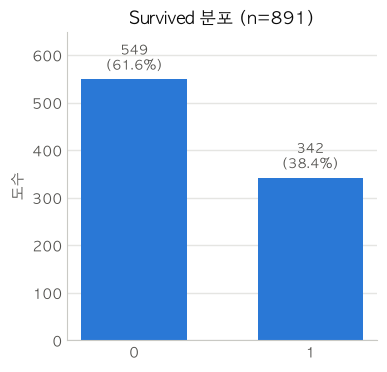

In [403]:
# Survied 비율 확인

plot_category_counts(train_df, "Survived", sort_by_count=False)
plt.show()

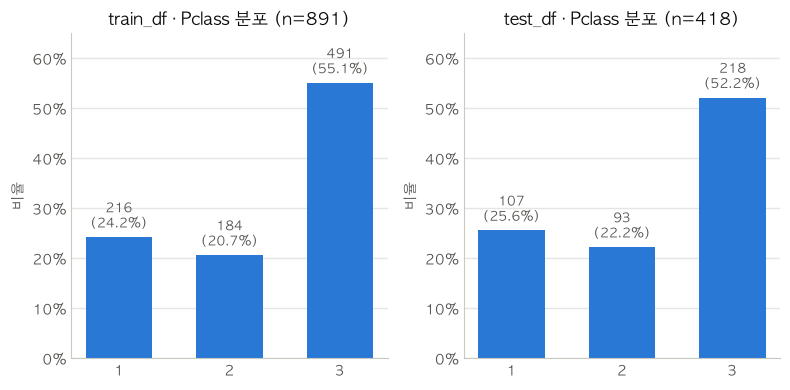

In [404]:
# Pclass 분포 확인

compare_category_counts({"train_df": train_df, "test_df": test_df}, "Pclass", sort_by_count=False)
plt.show()

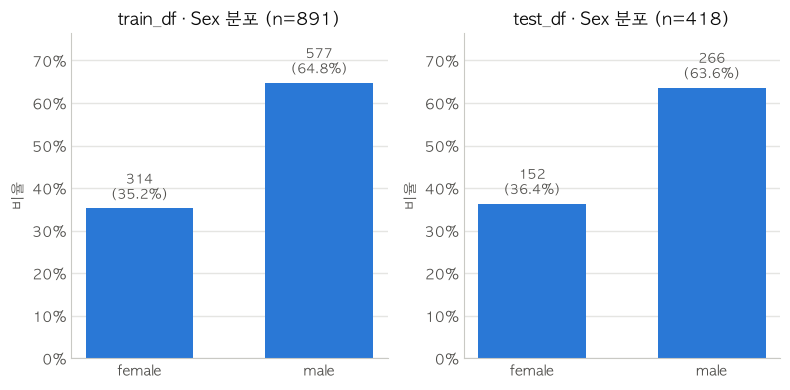

In [405]:
# Sex 분포 확인

compare_category_counts({"train_df": train_df, "test_df": test_df}, "Sex", sort_by_count=False)
plt.show()

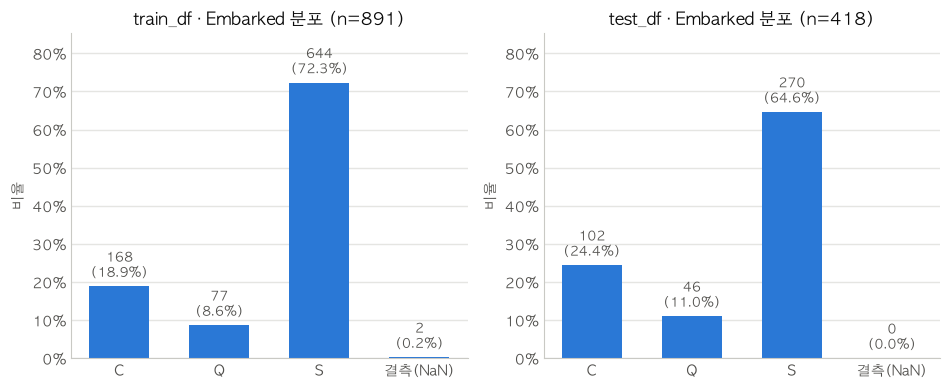

In [406]:
# Embarked(탑승 항구) 분포 확인

compare_category_counts({"train_df": train_df, "test_df": test_df}, "Embarked", sort_by_count=False)
plt.show()

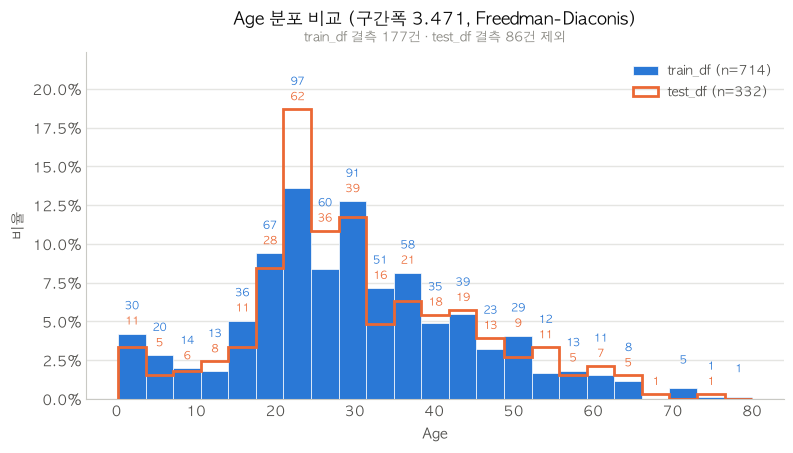

In [407]:
# Age 분포 확인
compare_histograms({"train_df": train_df, "test_df": test_df}, "Age")
plt.show()

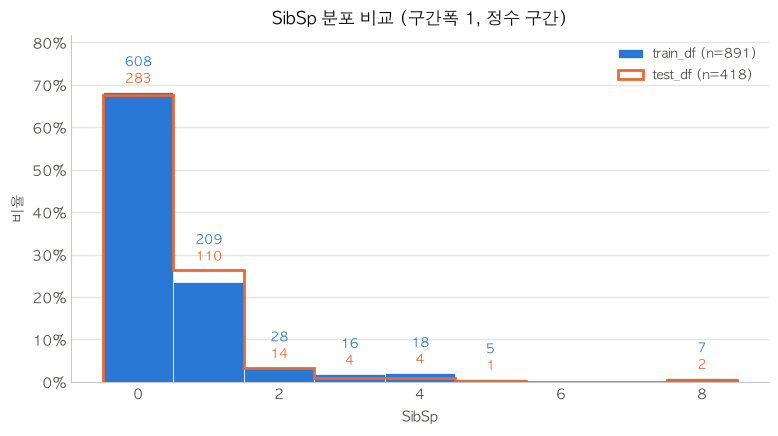

In [408]:
# SibSp(함께 탑승한 형제자매와 배우자 수) 분포 확인

compare_histograms({"train_df": train_df, "test_df": test_df}, "SibSp")
plt.show()

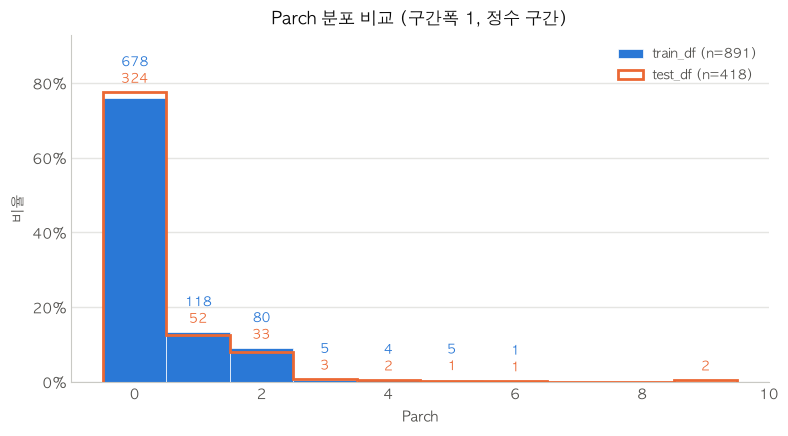

In [409]:
# Parch(함께 탑승한 부모와 자녀 수) 분포 확인

compare_histograms({"train_df": train_df, "test_df": test_df}, "Parch")
plt.show()

train_df          \
                                                   계급값       도수    상대도수   
Fare 계급 (구간폭 10.25, Freedman-Diaconis, 50구간 상한)                           
[0, 10.25)                                       5.123      337   37.8%   
[10.25, 20.49)                                   15.37      182   20.4%   
[20.49, 30.74)                                   25.62      147   16.5%   
[30.74, 40.99)                                   35.86       50    5.6%   
[40.99, 51.23)                                   46.11       16    1.8%   
[51.23, 61.48)                                   56.36       39    4.4%   
[61.48, 71.73)                                    66.6       18    2.0%   
[71.73, 81.97)                                   76.85       29    3.3%   
[81.97, 92.22)                                    87.1       18    2.0%   
[92.22, 102.5)                                   97.34        2    0.2%   
[102.5, 112.7)                                   107.6        8    0.9%   
[112.7, 123)                                     117.8        7    0.8%   
[123, 133.2)                                     128.1        0    0.0%   
[133.2, 143.5)                                   138.3        7    0.8%   
[143.5, 153.7)                                   148.6        9    1.0%   
[153.7, 163.9)                                   158.8        0    0.0%   
[163.9, 174.2)                                   169.1        2    0.2%   
[174.2, 184.4)                                   179.3        0    0.0%   
[184.4, 194.7)                                   189.6        0    0.0%   
[194.7, 204.9)                                   199.8        0    0.0%   
[204.9, 215.2)                                   210.1        4    0.4%   
[215.2, 225.4)                                   220.3        1    0.1%   
[225.4, 235.7)                                   230.5        4    0.4%   
[235.7, 245.9)                                   240.8        0    0.0%   
[245.9, 256.2)                                     251        2    0.2%   
[256.2, 266.4)                                   261.3        6    0.7%   
[266.4, 276.7)                                   271.5        0    0.0%   
[276.7, 286.9)                                   281.8        0    0.0%   
[286.9, 297.2)                                     292        0    0.0%   
[297.2, 307.4)                                   302.3        0    0.0%   
[307.4, 317.6)                                   312.5        0    0.0%   
[317.6, 327.9)                                   322.8        0    0.0%   
[327.9, 338.1)                                     333        0    0.0%   
[338.1, 348.4)                                   343.3        0    0.0%   
[348.4, 358.6)                                   353.5        0    0.0%   
[358.6, 368.9)                                   363.8        0    0.0%   
[368.9, 379.1)                                     374        0    0.0%   
[379.1, 389.4)                                   384.2        0    0.0%   
[389.4, 399.6)                                   394.5        0    0.0%   
[399.6, 409.9)                                   404.7        0    0.0%   
[409.9, 420.1)                                     415        0    0.0%   
[420.1, 430.4)                                   425.2        0    0.0%   
[430.4, 440.6)                                   435.5        0    0.0%   
[440.6, 450.8)                                   445.7        0    0.0%   
[450.8, 461.1)                                     456        0    0.0%   
[461.1, 471.3)                                   466.2        0    0.0%   
[471.3, 481.6)                                   476.5        0    0.0%   
[481.6, 491.8)                                   486.7        0    0.0%   
[491.8, 502.1)                                     497        0    0.0%   
[502.1, 512.3]                                   507.2        3    0.3%   
합계                                                   -      891  100.0%   
결측(Na

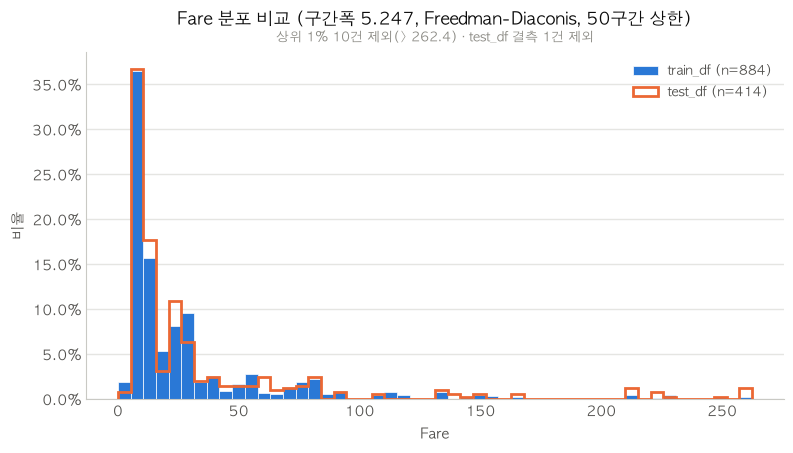

In [410]:
# Fare(운임) 분포 확인

display(frequency_table({"train_df": train_df, "test_df": test_df}, "Fare"))
compare_histograms({"train_df": train_df, "test_df": test_df}, "Fare", clip_quantile=0.99)
plt.show()

### 3. 결측 현황 확인 및 대응 계획 수립
#### 결론 1: Age, Cabin의 결측률은 생존률과 유의미한 연관이 있다. 따라서 둘의 결측을 나타내는 hasAge, hasCabin 플래그를 만들 필요가 있다. 
#### 결론 2: 결측 대응 전략
- Age: 결측이 3등석·Mr·Q 승선에 몰려 있으므로, 전체 중앙값이 아니라 Title × Pclass 조합의 중앙값으로 대치한다.
- Cabin: 결측 77%에 같은 티켓으로 복원되는 행이 0.9%뿐이라 대치는 포기하고, hasCabin 플래그와 관측분 Deck(Unknown 포함)만 쓴다.

In [411]:
print("train_df 결측 현황")
display(get_nullcnt_ratio_describe(train_df))
print("")
print("test_df 결측 현황")
display(get_nullcnt_ratio_describe(test_df))

train_df 결측 현황


,Null_Count,Null_Ratio,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Cabin,687,0.771044,204,147,G6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,177,0.198653,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
Embarked,2,0.002245,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN



test_df 결측 현황


,Null_Count,Null_Ratio,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Cabin,327,0.782297,91,76,B57 B59 B63 B66,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,86,0.205742,332.0,NaN,NaN,NaN,30.27259,14.181209,0.17,21.0,27.0,39.0,76.0
Fare,1,0.002392,417.0,NaN,NaN,NaN,35.627188,55.907576,0.0,7.8958,14.4542,31.5,512.3292


train_df         test_df        
             결측 컬럼 수       도수      비율      도수      비율
결측 패턴                                                
결측 없음              0      183   20.5%      87   20.8%
Cabin              1      529   59.4%     244   58.4%
Age                1       19    2.1%       4    1.0%
Embarked           1        2    0.2%       0    0.0%
Cabin + Age        2      158   17.7%      82   19.6%
Cabin + Fare       2        0    0.0%       1    0.2%
합계                 -      891  100.0%     418  100.0%

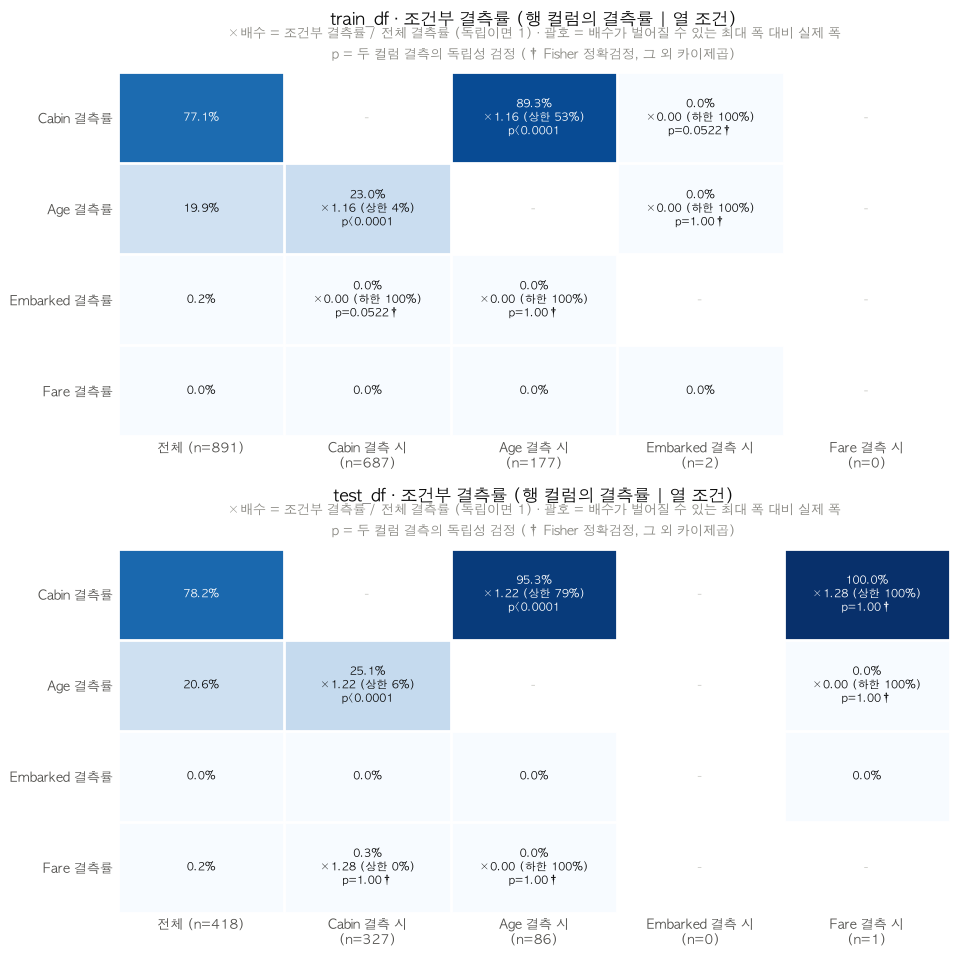

In [412]:
# 결측 동시 발생 패턴 확인: Cabin, Age, Embarked, Fare 중 일부 또는 모두가 같이 Nan인 경우를 확인
# 결측이 특정 승객군에 몰려있는 지 확인.

# 1. 결측 조합별 도수: 어떤 컬럼들이 함께 비어 있는지 확인
display(missing_pattern_table({"train_df": train_df, "test_df": test_df}, ["Cabin", "Age", "Embarked", "Fare"]))

# 2. 조건부 결측률: 한 컬럼이 결측일 때 다른 컬럼의 결측률이 전체 대비 달라지는지 확인
compare_missing_cooccurrence({"train_df": train_df, "test_df": test_df}, ["Cabin", "Age", "Embarked", "Fare"])
plt.show()

,결측 n,결측 Survived율,관측 n,관측 Survived율,차이(pp),검정,p-value,판정
결측 플래그 (기준 Survived율 38.4%),,,,,,,,
Age,177,29.4%,714,40.6%,-11.2pp,카이제곱 검정,0.00768,유의
Cabin,687,30.0%,204,66.7%,-36.7pp,카이제곱 검정,<0.0001,유의
Embarked,2,100.0%,889,38.2%,+61.8pp,Fisher 정확검정,0.147,유의하지 않음


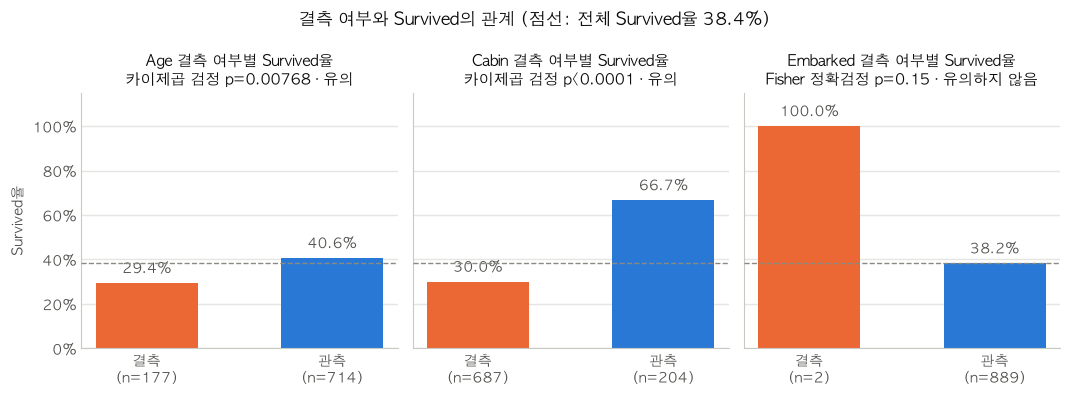

Age와 Cabin은 Survived와 유의미한 연관이 있다. 따라서 hasAge, hasCabin 별도 플래그 피처로 분리할 필요가 있다.


In [413]:
# '결측 플래그'와 '생존'의 관계 확인.
# Age, Cabin, Embarked 각각에 대해서 '결측 그룹 VS 관측 그룹'의 생존률 비교.
# 만약 차이가 유의미하다면 결측 자체를 별도 플래그로 남길 의미가 있다.

# Survived는 train_df에만 있으므로 train_df 기준으로 본다
display(missing_flag_target_table(train_df, ["Age", "Cabin", "Embarked"], target="Survived"))

plot_missing_flag_target(train_df, ["Age", "Cabin", "Embarked"], target="Survived")
plt.show()

print("Age와 Cabin은 Survived와 유의미한 연관이 있다. 따라서 hasAge, hasCabin 별도 플래그 피처로 분리할 필요가 있다.")

n Age 결측률 Cabin 결측률
기준 변수    그룹                                  
전체       -              891   19.9%     77.1%
Pclass   1              216   13.9%     18.5%
         2              184    6.0%     91.3%
         3              491   27.7%     97.6%
Sex      female         314   16.9%     69.1%
         male           577   21.5%     81.5%
Embarked C              168   22.6%     58.9%
         Q               77   63.6%     94.8%
         S              644   14.0%     80.0%
         결측(NaN)          2    0.0%      0.0%
SibSp    0              608   22.5%     79.3%
         1              209   12.4%     67.0%
         2               28   10.7%     78.6%
         3               16   25.0%     81.2%
         4               18    0.0%    100.0%
         5                5    0.0%    100.0%
         8                7  100.0%    100.0%
Parch    0              678   23.2%     79.2%
         1              118    6.8%     66.9%
         2               80   15.0%     71.2%
         3                5    0.0%    100.0%
         4                4    0.0%     75.0%
         5                5    0.0%    100.0%
         6                1    0.0%    100.0%
Fare     [0, 7.91]      223   35.9%     96.4%
         (7.91, 14.45]  224   10.7%     92.9%
         (14.45, 31]    222   20.3%     81.5%
         (31, 512.3]    222   12.6%     37.4%

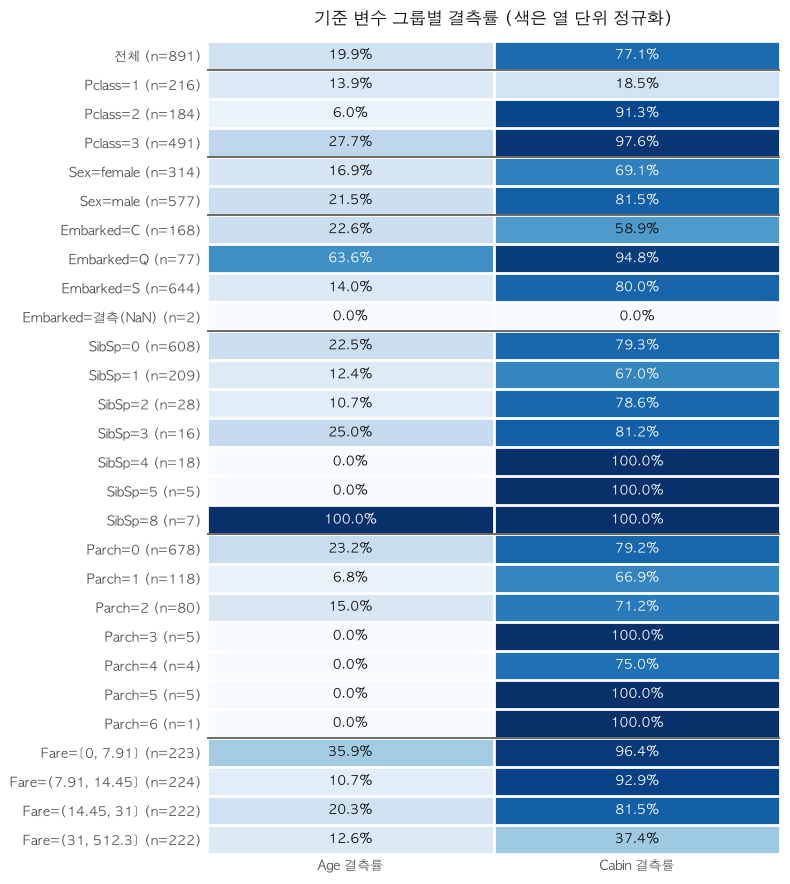

Cabin: Pclass=3, Sex=male, Embarked=Q에서 결측이 뚜렷해보인다.
Age: Pclass=3, Sex=male, Embarked=Q에서 결측이 뚜렷해보인다.


In [414]:
# '결측 플래그'와 '다른 변수'의 관계 확인.
# 특정 변수 그룹에서 결측률이 뚜렷하다면, 그룹 별로 대체가 필요하다.

# 결측이 많은 Age, Cabin을 대상으로, 대체 기준이 될 만한 변수들로 그룹을 나눠 결측률을 본다
# (Embarked 2건, Fare 1건은 표본이 너무 적어 그룹별로 쪼개는 의미가 없다)
display(missing_rate_by_group(train_df, ["Age", "Cabin"], ["Pclass", "Sex", "Embarked", "SibSp", "Parch", "Fare"]))

plot_missing_rate_by_group(train_df, ["Age", "Cabin"], ["Pclass", "Sex", "Embarked", "SibSp", "Parch", "Fare"])
plt.show()

print("Cabin: Pclass=3, Sex=male, Embarked=Q에서 결측이 뚜렷해보인다.\nAge: Pclass=3, Sex=male, Embarked=Q에서 결측이 뚜렷해보인다.")

#### Age의 분포 형태 확인: 셋 중 하나를 결정한다. column drop / 존재 여부 플래그 / 대치

n   결측    평균  표준편차    최소    Q1   중앙값    Q3    최대   IQR
기준 변수  그룹                                                              
전체     -       891  177  29.7  14.5   0.4  20.1  28.0  38.0  80.0  17.9
Title  Master   40    4   4.6   3.6   0.4   1.0   3.5   8.0  12.0   7.0
       Miss    185   36  21.8  12.9   0.8  14.5  21.0  30.0  63.0  15.5
       Mr      517  119  32.4  12.7  11.0  23.0  30.0  39.0  80.0  16.0
       Mrs     126   17  35.8  11.4  14.0  27.0  35.0  44.0  63.0  17.0
       기타       23    1  45.5  11.8  23.0  38.5  48.5  53.5  70.0  15.0
Pclass 1       216   30  38.2  14.8   0.9  27.0  37.0  49.0  80.0  22.0
       2       184   11  29.9  14.0   0.7  23.0  29.0  36.0  70.0  13.0
       3       491  136  25.1  12.5   0.4  18.0  24.0  32.0  74.0  14.0
Sex    female  314   53  27.9  14.1   0.8  18.0  27.0  37.0  63.0  19.0
       male    577  124  30.7  14.7   0.4  21.0  29.0  39.0  80.0  18.0
SibSp  0       608  137  31.4  13.6   0.4  22.0  29.0  39.0  80.0  17.0
       1       209   26  30.1  14.6   0.7  20.0  30.0  39.0  70.0  19.0
       2        28    3  22.6  14.7   0.8  16.0  23.0  28.0  53.0  12.0
       3        16    4  13.9  11.3   2.0   3.8   9.5  23.2  33.0  19.5
       4        18    0   7.1   4.9   1.0   3.2   6.5   9.0  17.0   5.8
       5         5    0  10.2   5.8   1.0   9.0  11.0  14.0  16.0   5.0
       8         7    7     -     -     -     -     -     -     -     -
Parch  0       678  157  32.2  12.6   5.0  22.0  30.0  39.0  80.0  17.0
       1       118    8  24.4  18.3   0.4   6.2  23.0  39.0  70.0  32.8
       2        80   12  17.2  13.2   0.8   5.8  16.5  25.0  58.0  19.2
       3         5    0  33.2  16.7  16.0  24.0  24.0  48.0  54.0  24.0
       4         4    0  44.5  14.6  29.0  37.2  42.5  49.8  64.0  12.5
       5         5    0  39.2   1.1  38.0  39.0  39.0  39.0  41.0   0.0
       6         1    0  43.0     -  43.0  43.0  43.0  43.0  43.0   0.0

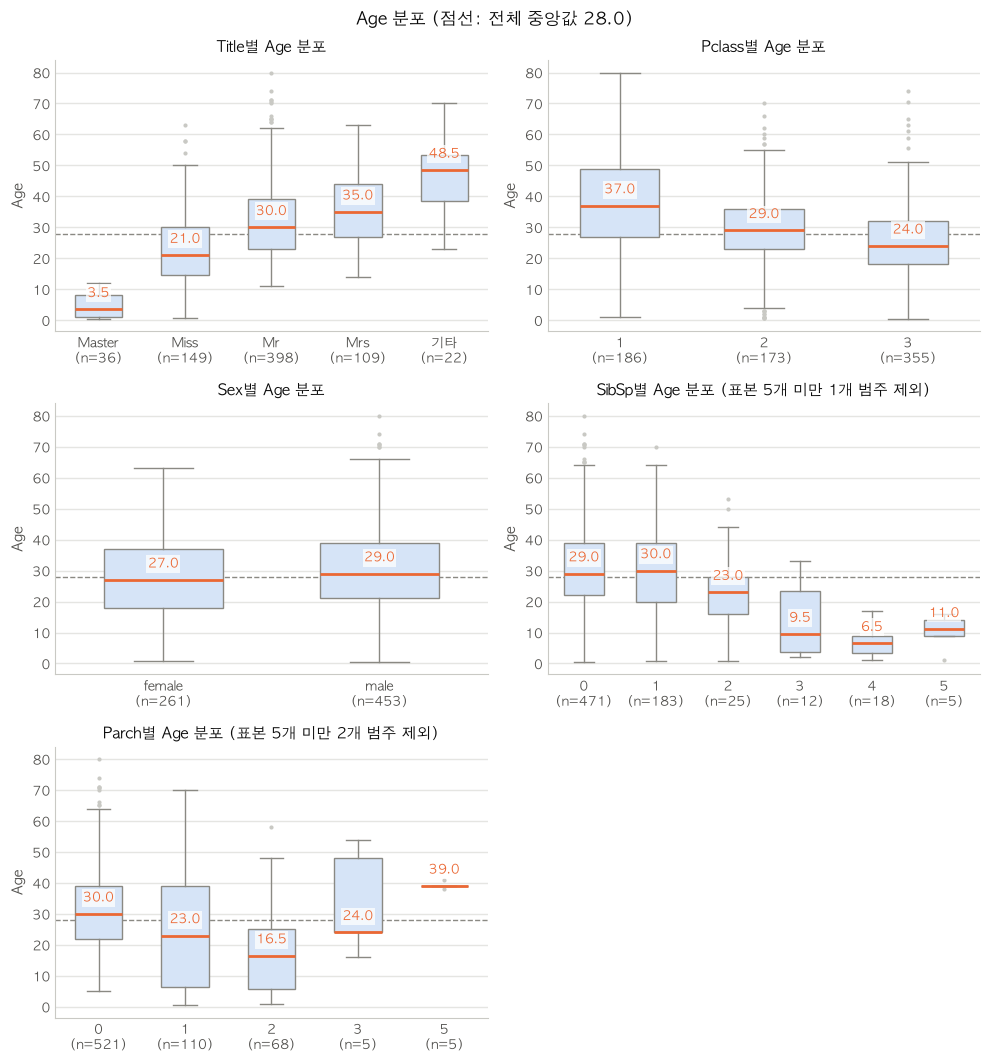

n   결측    평균  표준편차    최소    Q1   중앙값    Q3    최대  \
기준 변수          그룹                                                               
전체             -           891  177  29.7  14.5   0.4  20.1  28.0  38.0  80.0   
Title × Pclass Master × 1    3    0   5.3   5.2   0.9   2.5   4.0   7.5  11.0   
               Master × 2    9    0   2.3   2.3   0.7   0.8   1.0   3.0   8.0   
               Master × 3   28    4   5.4   3.6   0.4   2.0   4.0   9.0  12.0   
               Miss × 1     48    1  29.7  12.6   2.0  21.5  30.0  36.0  63.0   
               Miss × 2     35    2  22.6  13.2   2.0  13.0  24.0  30.0  50.0   
               Miss × 3    102   33  16.1   9.7   0.8   9.0  18.0  22.0  45.0   
               Mr × 1      107   20  41.6  14.1  17.0  29.5  40.0  50.5  80.0   
               Mr × 2       91    9  32.8  11.9  16.0  24.2  31.0  36.4  70.0   
               Mr × 3      319   90  28.7  10.5  11.0  21.0  26.0  34.0  74.0   
               Mrs × 1      43    8  40.4  12.8  17.0  35.0  40.0  50.5  62.0   
               Mrs × 2      41    0  33.7  10.3  14.0  26.0  32.0  41.0  57.0   
               Mrs × 3      42    9  33.5  10.0  15.0  27.0  31.0  40.0  63.0   
               기타 × 1       15    1  47.6  10.3  32.0  41.0  48.5  51.5  70.0   
               기타 × 2        8    0  42.0  14.0  23.0  27.8  46.5  54.0  57.0   

                            IQR  
기준 변수          그룹                
전체             -           17.9  
Title × Pclass Master × 1   5.0  
               Master × 2   2.2  
               Master × 3   7.0  
               Miss × 1    14.5  
               Miss × 2    17.0  
               Miss × 3    13.0  
               Mr × 1      21.0  
               Mr × 2      12.1  
               Mr × 3      13.0  
               Mrs × 1     15.5  
               Mrs × 2     15.0  
               Mrs × 3     13.0  
               기타 × 1      10.5  
               기타 × 2      26.2

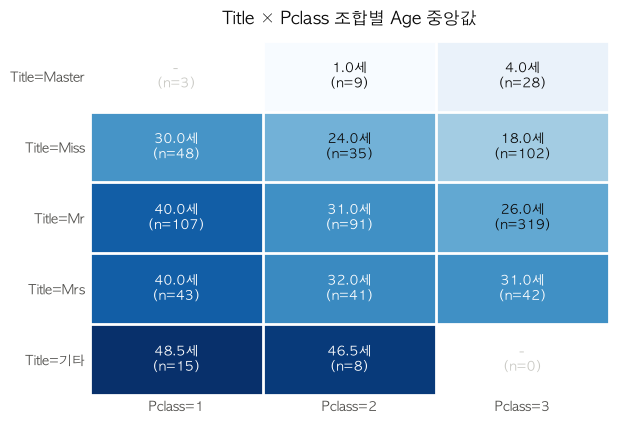

In [415]:
# Title(Name에서 Mr / Mrs / Miss / Master / 기타), Pclass, Sex, SibSp, Parch 각각 및 조합(Title×Pclass)에 대해
# 각 범주 별로 평균, 표준편차, 최소, 최대, 중앙값, IQR을 확인한다.
# 목표: 각 Title 별 Age 결측치를 대치할 만한 값을 확보한다.

# Title은 이 절 이후로도 계속 쓰므로 파생 컬럼으로 만들어 둔다
train_df["Title"] = extract_title(train_df["Name"])
test_df["Title"] = extract_title(test_df["Name"])

AGE_GROUP_COLS = ["Title", "Pclass", "Sex", "SibSp", "Parch"]

# 1. 기준 변수별 Age 기술통계 (대치값 후보를 고르기 위한 표)
display(group_stats_table(train_df, "Age", AGE_GROUP_COLS))

# 2. 분포 형태 확인: 평균과 중앙값 중 무엇으로 채울지, 그룹을 나눌 만큼 차이가 큰지 본다
plot_group_boxplots(train_df, "Age", AGE_GROUP_COLS, ncols=2, min_count=5)
plt.show()

# 3. Title × Pclass 조합: 실제 대치 기준으로 쓸 조합별 중앙값과 표본 수
display(group_stats_table(train_df, "Age", [("Title", "Pclass")]))
plot_group_matrix(train_df, "Title", "Pclass", "Age", agg="median", fmt="{:,.1f}세",
                  min_count=5, normalize="matrix", title="Title × Pclass 조합별 Age 중앙값")
plt.show()

결측 n  결측 비율 관측 n  관측 비율   차이(pp)     배수
기준 변수    그룹                                             
Pclass   1         30  16.9%  186  26.1%   -9.1pp  ×0.65
         2         11   6.2%  173  24.2%  -18.0pp  ×0.26
         3        136  76.8%  355  49.7%  +27.1pp  ×1.55
Title    Master     4   2.3%   36   5.0%   -2.8pp  ×0.45
         Miss      36  20.3%  149  20.9%   -0.5pp  ×0.97
         Mr       119  67.2%  398  55.7%  +11.5pp  ×1.21
         Mrs       17   9.6%  109  15.3%   -5.7pp  ×0.63
         기타         1   0.6%   22   3.1%   -2.5pp  ×0.18
Embarked C         38  21.5%  130  18.2%   +3.3pp  ×1.18
         Q         49  27.7%   28   3.9%  +23.8pp  ×7.06
         S         90  50.8%  554  77.6%  -26.7pp  ×0.66
         결측(NaN)    0   0.0%    2   0.3%   -0.3pp  ×0.00
Parch    0        157  88.7%  521  73.0%  +15.7pp  ×1.22
         1          8   4.5%  110  15.4%  -10.9pp  ×0.29
         2         12   6.8%   68   9.5%   -2.7pp  ×0.71
         3          0   0.0%    5   0.7%   -0.7pp  ×0.00
         4          0   0.0%    4   0.6%   -0.6pp  ×0.00
         5          0   0.0%    5   0.7%   -0.7pp  ×0.00
         6          0   0.0%    1   0.1%   -0.1pp  ×0.00

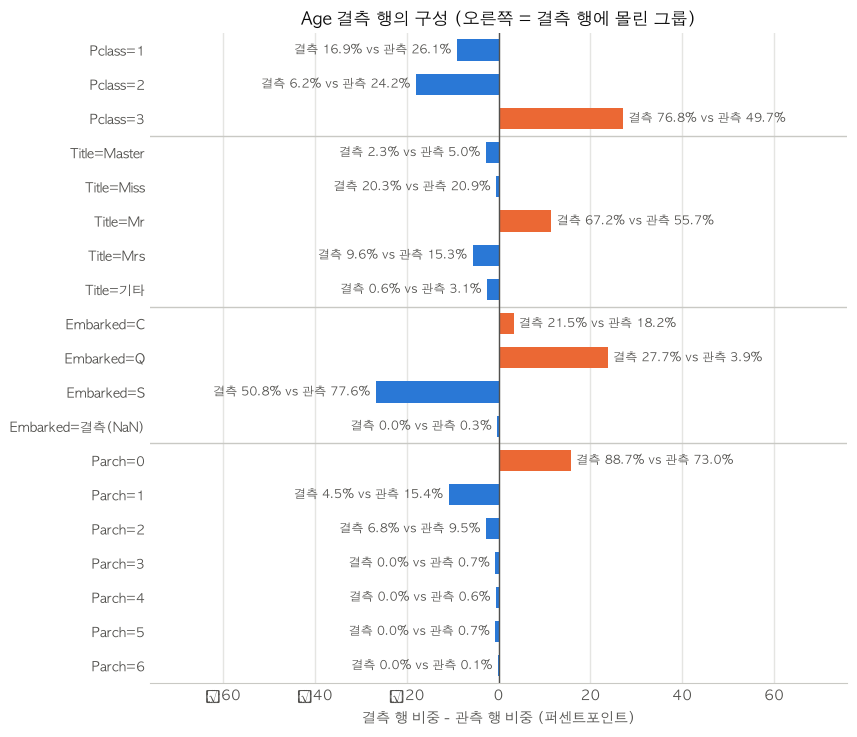

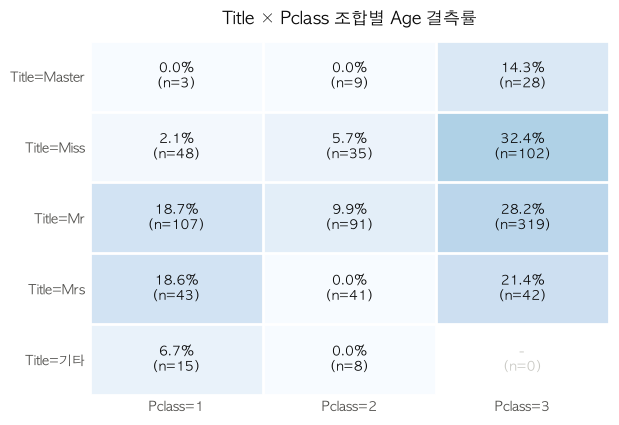

Age 결측은 무작위가 아니다: 3등석(76.8% vs 49.7%), Q 승선(27.7% vs 3.9%), Mr, 동반자 없는 승객에 몰려 있다.
→ column drop: Age는 Title별로 중앙값이 3.5세(Master)~48.5세(기타)까지 갈리는 강한 신호라 버릴 수 없다.
→ 전체 중앙값 대치: 결측이 3등석·Mr에 몰려 있어 전체값(28.0세)으로 채우면 그 그룹의 나이를 위로 왜곡한다.
→ 전략 확정: hasAge 플래그를 남기고, Age는 Title × Pclass 조합의 중앙값으로 대치한다.
   (조합 표본이 5명 미만이면 Title 중앙값 -> 전체 중앙값 순으로 물러난다.)


In [416]:
# 결측 Age 행의 프로필: 결측인 행의 Pclass, Title, Embarked, Parch 분포를 비결측 행과 비교한다.
# 결측이 특정 그룹에 몰려 있으면, 그 그룹의 통계로 채워야 한다는 근거가 된다.

AGE_PROFILE_COLS = ["Pclass", "Title", "Embarked", "Parch"]

# 결측 행과 관측 행이 각각 어떤 승객으로 이루어져 있는지 비교한다
display(missing_profile_table(train_df, "Age", AGE_PROFILE_COLS))

plot_missing_profile(train_df, "Age", AGE_PROFILE_COLS)
plt.show()

# 대치 기준으로 쓸 Title × Pclass 조합에서, 결측이 실제로 어디에 몰려 있는지 확인한다
plot_group_matrix(train_df, "Title", "Pclass", "Age", agg=lambda s: s.isna().mean(),
                  fmt="{:.1%}", normalize="all", title="Title × Pclass 조합별 Age 결측률")
plt.show()

print(
    "Age 결측은 무작위가 아니다: 3등석(76.8% vs 49.7%), Q 승선(27.7% vs 3.9%), Mr, 동반자 없는 승객에 몰려 있다.\n"
    "→ column drop: Age는 Title별로 중앙값이 3.5세(Master)~48.5세(기타)까지 갈리는 강한 신호라 버릴 수 없다.\n"
    "→ 전체 중앙값 대치: 결측이 3등석·Mr에 몰려 있어 전체값(28.0세)으로 채우면 그 그룹의 나이를 위로 왜곡한다.\n"
    "→ 전략 확정: hasAge 플래그를 남기고, Age는 Title × Pclass 조합의 중앙값으로 대치한다.\n"
    "   (조합 표본이 5명 미만이면 Title 중앙값 -> 전체 중앙값 순으로 물러난다.)"
)

#### Cabin의 분포 형태 확인: 세 전략 중 하나를 결정한다. column drop / 존재 여부 플래그 / 대치 후 덱(Deck), 객실방향(Side) 추출

Cabin 결측률              행 수        
        train_df test_df train_df test_df
Pclass                                   
1          18.5%   25.2%      216     107
2          91.3%   92.5%      184      93
3          97.6%   98.2%      491     218

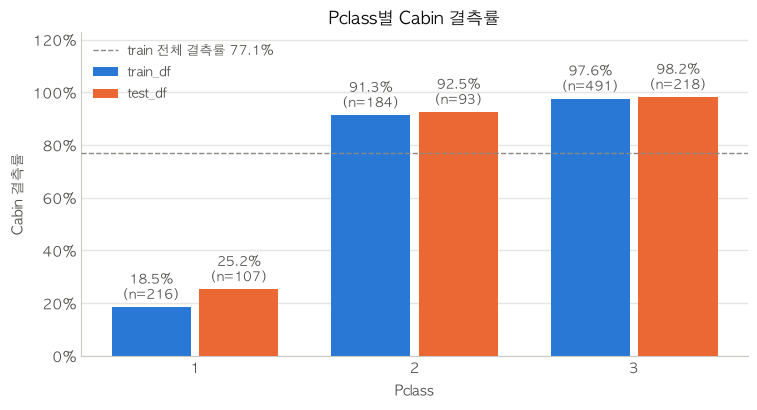

,n,Pclass 범주 수,Cramér's V,p-value,최빈값 규칙 정확도,기저 정확도,개선폭
연관 강도 (카이제곱 검정),,,,,,,
Pclass → Cabin 관측,891,3,0.791,9.59e-122,92.4%,77.1%,+15.3%


In [417]:
# Pclass별 Cabin 결측률: 1등석은 대부분 있고 3등석은 거의 없다면, Cabin_known이 사실상 Pclass의 대리 변수일 수 있다.

# 1. Pclass별 Cabin 결측률 (train/test에서 같은 패턴인지 함께 확인)
cabin_rates, cabin_counts = group_rate_frame(
    {"train_df": train_df, "test_df": test_df}, "Pclass", "Cabin", agg=lambda s: s.isna().mean()
)
display(format_table(pd.concat({"Cabin 결측률": cabin_rates, "행 수": cabin_counts}, axis=1), {"결측률": "{:.1%}"}))

plot_rate_bars(cabin_rates, cabin_counts, title="Pclass별 Cabin 결측률", ylabel="Cabin 결측률",
               baseline=train_df["Cabin"].isna().mean(), baseline_label="train 전체 결측률")
plt.show()

# 2. '대리 변수'인지 판정: Pclass만 보고 Cabin 유무를 얼마나 맞힐 수 있는지 확인한다
display(association_summary(train_df["Pclass"], train_df["Cabin"].notna().rename("Cabin 관측")))

,Cabin 결측 n,Cabin 결측 Survived율,Cabin 관측 n,Cabin 관측 Survived율,차이(pp),검정,p-value,판정
Pclass 층 (Cabin 결측 vs Cabin 관측),,,,,,,,
전체,687,30.0%,204,66.7%,-36.7pp,카이제곱 검정,p<0.0001,유의
1,40,47.5%,176,66.5%,-19.0pp,카이제곱 검정,0.0392,유의
2,168,44.0%,16,81.2%,-37.2pp,카이제곱 검정,0.00971,유의
3,479,23.6%,12,50.0%,-26.4pp,Fisher 정확검정,0.0795,유의하지 않음


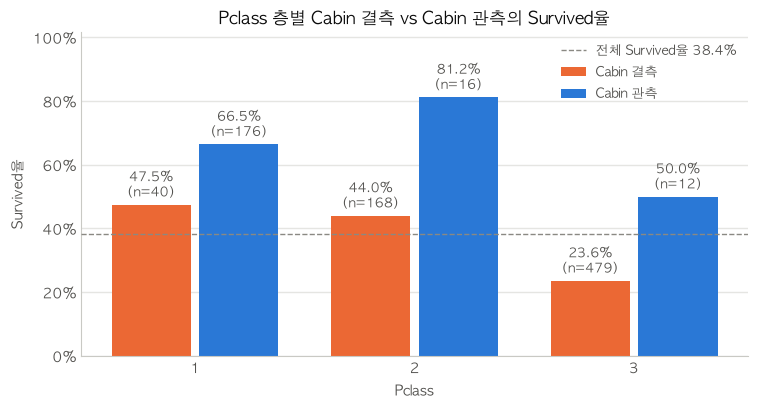

,Cabin 결측 n,Cabin 결측 Survived율,Cabin 관측 n,Cabin 관측 Survived율,차이(pp),검정,p-value,판정
Sex 층 (Cabin 결측 vs Cabin 관측),,,,,,,,
전체,687,30.0%,204,66.7%,-36.7pp,카이제곱 검정,p<0.0001,유의
female,217,65.4%,97,93.8%,-28.4pp,카이제곱 검정,p<0.0001,유의
male,470,13.6%,107,42.1%,-28.4pp,카이제곱 검정,p<0.0001,유의


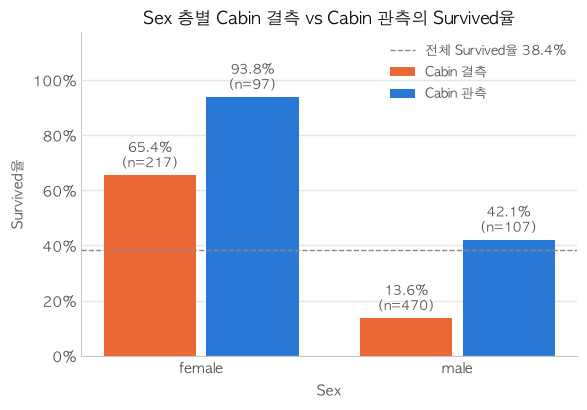

In [418]:
# Pclass를 고정한 상태에서 Cabin 유무별 생존률: 같은 1등급이더라도 Cabin 관측/결측에 따라서 생존률 차이가 유의미하다면, 플래그로 쓸 가치가 있다.

# 층(Pclass) 안에서도 차이가 남는지 확인한다. 전체에서만 차이가 나고 층 안에서 사라지면
# Cabin 유무는 Pclass를 다시 말한 것에 지나지 않는다.
display(stratified_target_table(train_df, target="Survived", stratum_col="Pclass", flag_col="Cabin"))

plot_stratified_target(train_df, target="Survived", stratum_col="Pclass", flag_col="Cabin")
plt.show()

# 성별로도 같은 확인 (Pclass 하나로 설명되지 않는지 교차 확인)
display(stratified_target_table(train_df, target="Survived", stratum_col="Sex", flag_col="Cabin"))

plot_stratified_target(train_df, target="Survived", stratum_col="Sex", flag_col="Cabin")
plt.show()

,결측,복원 가능,값 충돌,복원 불가,복원율
Ticket 공유 행으로 복원,,,,,
Cabin,"1,014",9,7,998,0.9%
Embarked,2,0,0,2,0.0%
Fare,1,0,0,1,0.0%


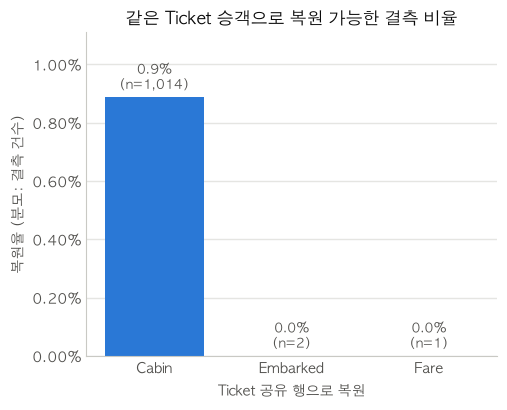

,PassengerId,Name,Pclass,Ticket,Cabin,복원값
290,291,"Barber, Miss. Ellen ""Nellie""",1,19877,NaN,C46
533,534,"Peter, Mrs. Catherine (Catherine Rizk)",3,2668,NaN,F E69
537,538,"LeRoy, Miss. Bertha",1,PC 17761,NaN,C86
708,709,"Cleaver, Miss. Alice",1,113781,NaN,C22 C26
841,842,"Mudd, Mr. Thomas Charles",2,S.O./P.P. 3,NaN,E77
856,857,"Wick, Mrs. George Dennick (Mary Hitchcock)",1,36928,NaN,C7
1032,1033,"Daniels, Miss. Sarah",1,113781,NaN,C22 C26
1108,1109,"Wick, Mr. George Dennick",1,36928,NaN,C7
1308,1309,"Peter, Master. Michael J",3,2668,NaN,F E69


In [419]:
# 같은 Ticket 승객의 Cabin
# Cabin이 없는 행 중 같은 티켓을 가진 다른 승객이 Cabin을 갖고 있는 경우가 몇 건인 지 파악한다.
# 이 경우에는 그 다른 승객의 Cabin으로 값을 복원할 수 있다.

# 같은 티켓이 train과 test에 나뉘어 있을 수 있으므로 두 데이터를 합쳐서 본다
all_df = pd.concat([train_df, test_df], ignore_index=True)

# Cabin 외에 Embarked, Fare도 같은 방식으로 복원되는지 함께 확인한다
recovered = {}
summaries = []
for column in ["Cabin", "Embarked", "Fare"]:
    summary, filled = recoverable_by_key(all_df, "Ticket", column)
    summaries.append(summary)
    recovered[column] = filled

recovery = pd.concat(summaries)
display(format_table(recovery, {"복원율": "{:.1%}"}))

plot_rate_bars(recovery[["복원율"]], recovery[["결측"]], title="같은 Ticket 승객으로 복원 가능한 결측 비율",
               ylabel="복원율 (분모: 결측 건수)")
plt.show()

# 복원되는 Cabin 행 예시
cabin_filled = recovered["Cabin"]
display(
    all_df.loc[cabin_filled.notna(), ["PassengerId", "Name", "Pclass", "Ticket", "Cabin"]]
    .assign(복원값=cabin_filled)
    .head(10)
)

train_df         test_df        
                    도수    상대도수      도수    상대도수
Deck 계급 (범주형)                                 
A                   15    1.7%       7    1.7%
B                   47    5.3%      18    4.3%
C                   59    6.6%      35    8.4%
D                   33    3.7%      13    3.1%
E                   32    3.6%       9    2.2%
F                   13    1.5%       8    1.9%
G                    4    0.4%       1    0.2%
T                    1    0.1%       0    0.0%
결측(NaN)            687   77.1%     327   78.2%
합계                 891  100.0%     418  100.0%

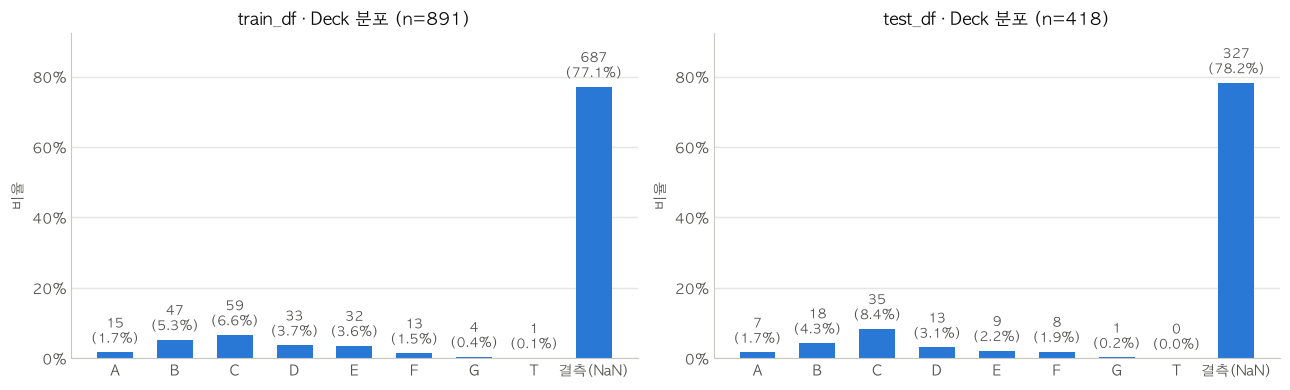

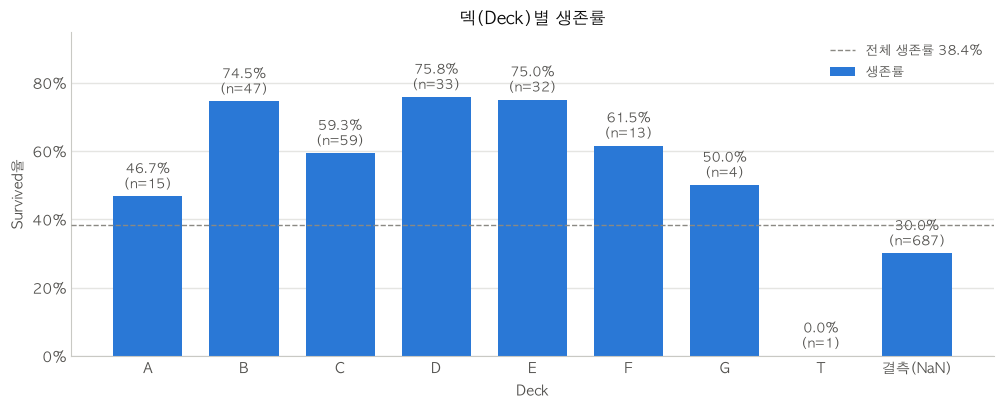

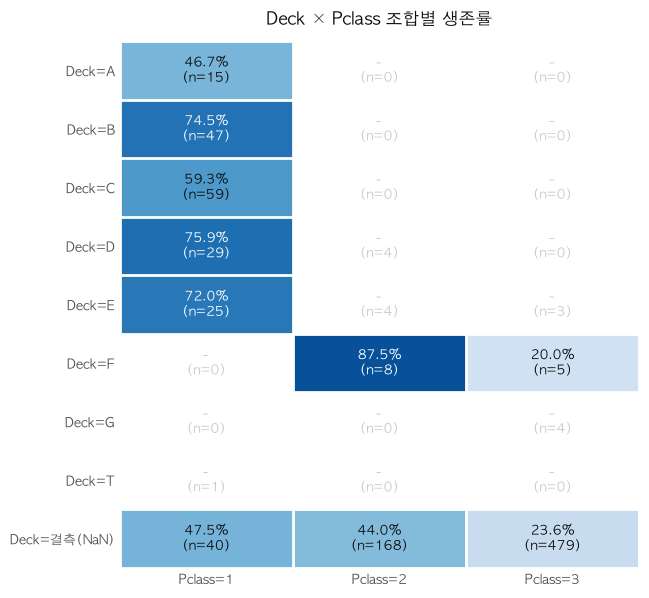

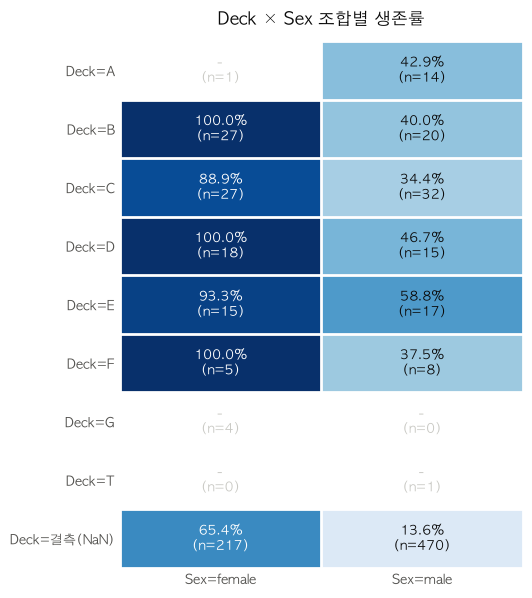

덱별 생존률 차이 (전체, n=204): 카이제곱 검정(기대도수 부족) p=0.17
덱별 생존률 차이 (Pclass=1 안, n=176): 카이제곱 검정(기대도수 부족) p=0.12


In [420]:
# 덱(Deck) 문자 분포와 개수:
# 관측된 Cabin의 맨 앞 알파벳 분포를 파악하고, 각각 몇 명인 지 파악한다.
# 전체, 그리고 주요 변수들의 범주 사이에서 Deck 알파벳 별로 생존률을 비교한다.

train_df["Deck"] = extract_deck(train_df["Cabin"])
test_df["Deck"] = extract_deck(test_df["Cabin"])

# 1. 덱 문자 분포와 인원 (Cabin 결측은 별도 범주로 함께 표시)
display(frequency_table({"train_df": train_df, "test_df": test_df}, "Deck"))
compare_category_counts({"train_df": train_df, "test_df": test_df}, "Deck", sort_by_count=False,
                        figsize=(13, 4))
plt.show()

# 2. 덱별 생존률
deck_rates, deck_counts = group_rate_frame(train_df, "Deck", "Survived")
plot_rate_bars(deck_rates.set_axis(["생존률"], axis=1), deck_counts, title="덱(Deck)별 생존률",
               ylabel="Survived율", baseline=train_df["Survived"].mean(), baseline_label="전체 생존률")
plt.show()

# 3. Pclass, Sex를 고정해도 덱 차이가 남는지 확인 (덱이 등급/성별의 대리 변수인지 판단)
plot_group_matrix(train_df, "Deck", "Pclass", "Survived", normalize="all", min_count=5,
                  title="Deck × Pclass 조합별 생존률")
plt.show()
plot_group_matrix(train_df, "Deck", "Sex", "Survived", normalize="all", min_count=5,
                  title="Deck × Sex 조합별 생존률")
plt.show()

# 4. 눈에 보이는 덱별 차이가 우연인지 검정한다 (관측된 Cabin 204명뿐이라 표본이 작다)
observed_deck = train_df[train_df["Deck"].notna()]
for name, subset in [("전체", observed_deck), ("Pclass=1 안", observed_deck[observed_deck["Pclass"] == 1])]:
    deck_test, deck_p = independence_test(pd.crosstab(subset["Deck"], subset["Survived"]).to_numpy())
    print(f"덱별 생존률 차이 ({name}, n={len(subset):,}): {deck_test} {format_pvalue(deck_p, deck_test)}")

train_df         test_df        
                    도수    상대도수      도수    상대도수
Side 계급 (범주형)                                 
Missing            687   77.1%     327   78.2%
Port               108   12.1%      45   10.8%
Starboard           88    9.9%      41    9.8%
Unknown              8    0.9%       5    1.2%
합계                 891  100.0%     418  100.0%

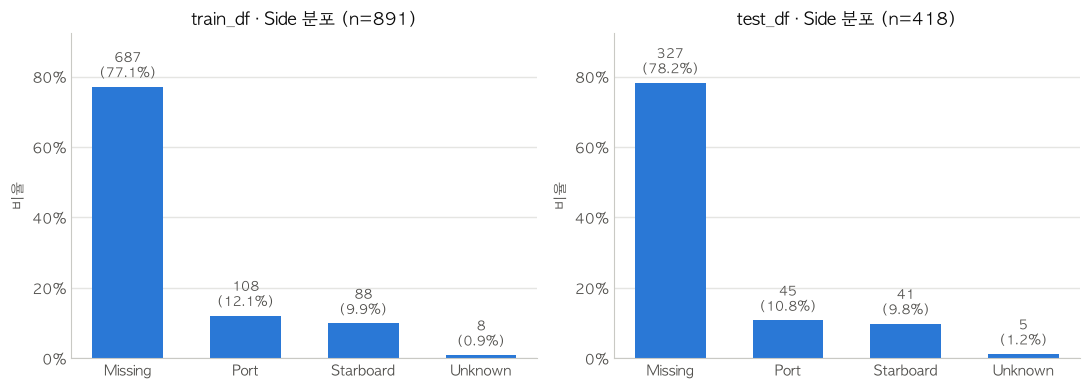

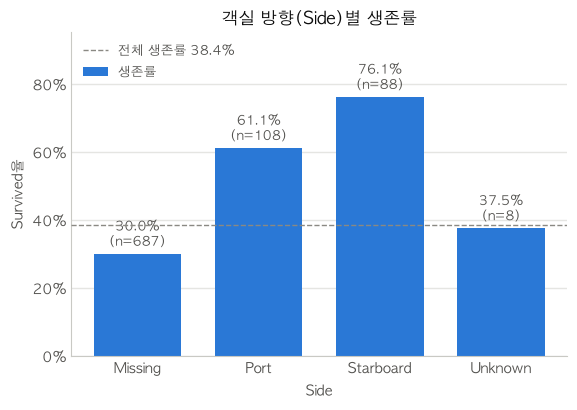

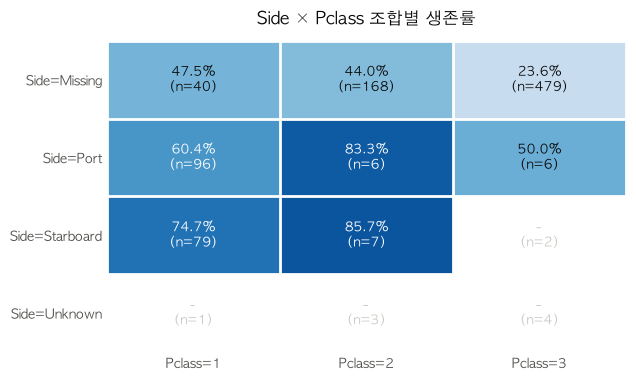

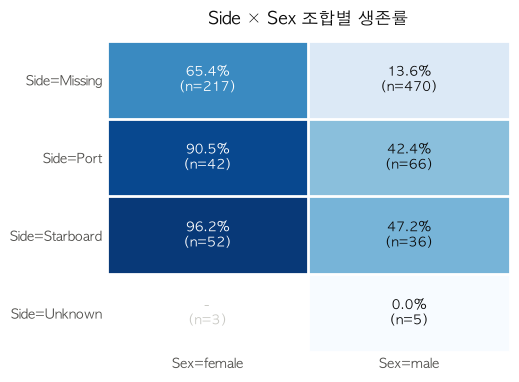

,Port n,Port Survived율,Starboard n,Starboard Survived율,차이(pp),검정,p-value,판정
Sex 층 (Port vs Starboard),,,,,,,,
전체,108,61.1%,88,76.1%,-15.0pp,카이제곱 검정,0.0369,유의
female,42,90.5%,52,96.2%,-5.7pp,Fisher 정확검정,0.40,유의하지 않음
male,66,42.4%,36,47.2%,-4.8pp,카이제곱 검정,0.80,유의하지 않음


Sex,female,male
Side,,
Port,38.9%,61.1%
Starboard,59.1%,40.9%


Cabin 전략 확정: 'column drop'도 '전면 대치'도 아닌 '존재 여부 플래그 + 관측분 파생'을 택한다.
- 전면 대치 불가: 결측이 77%인데 같은 티켓으로 복원되는 행은 9건(0.9%)뿐이다.
- drop 불가: Pclass와 Sex를 고정해도 Cabin 유무에 따라 생존률이 갈린다(1·2등석 p<0.05, 남녀 각각 p<0.0001).
- Deck: 관측된 204명에만 있고 덱별 생존률 차이는 유의하지 않다. 'Unknown'을 포함한 보조 범주로만 만든다.
- Side: 전체로는 차이가 보이지만(p=0.037) 성별을 고정하면 사라진다. 좌우 성별 구성 차이에 따른 착시이므로 쓰지 않는다.


In [421]:
# 객실 방향(Side)
# 관측된 Cabin의 알파벳 뒤 숫자. 짝수면 'Port'(좌현), 홀수면 'Starboard'(우현), 없으면 'Unknown'
# 전체, 그리고 주요 변수들의 범주 사이에서 Side 별로 생존을 비교한다.

train_df["Side"] = extract_side(train_df["Cabin"])
test_df["Side"] = extract_side(test_df["Cabin"])

# 1. 객실 방향 분포와 인원 (Cabin 결측은 별도 범주, 번호가 없는 객실은 Unknown)
display(frequency_table({"train_df": train_df, "test_df": test_df}, "Side"))
compare_category_counts({"train_df": train_df, "test_df": test_df}, "Side", sort_by_count=False,
                        figsize=(11, 4))
plt.show()

# 2. 방향별 생존률
side_rates, side_counts = group_rate_frame(train_df, "Side", "Survived")
plot_rate_bars(side_rates.set_axis(["생존률"], axis=1), side_counts, title="객실 방향(Side)별 생존률",
               ylabel="Survived율", baseline=train_df["Survived"].mean(), baseline_label="전체 생존률")
plt.show()

# 3. Pclass, Sex를 고정해도 방향 차이가 남는지 확인
plot_group_matrix(train_df, "Side", "Pclass", "Survived", normalize="all", min_count=5,
                  title="Side × Pclass 조합별 생존률")
plt.show()
plot_group_matrix(train_df, "Side", "Sex", "Survived", normalize="all", min_count=5,
                  title="Side × Sex 조합별 생존률")
plt.show()

# 4. 좌우 차이가 진짜인지 확인: 전체에서 차이가 보여도 두 방향의 성별 구성이 다르면 그 탓일 수 있다
observed_side = train_df[train_df["Side"].isin(["Port", "Starboard"])]
display(split_target_table(observed_side, target="Survived", stratum_col="Sex",
                           split=observed_side["Side"].eq("Port"), labels=("Port", "Starboard")))

# 방향별 성별 구성 (성별이 생존률을 가장 크게 가르므로, 구성이 다르면 좌우 차이는 착시다)
display(format_table(pd.crosstab(observed_side["Side"], observed_side["Sex"], normalize="index"), {"": "{:.1%}"}))

print(
    "Cabin 전략 확정: 'column drop'도 '전면 대치'도 아닌 '존재 여부 플래그 + 관측분 파생'을 택한다.\n"
    "- 전면 대치 불가: 결측이 77%인데 같은 티켓으로 복원되는 행은 9건(0.9%)뿐이다.\n"
    "- drop 불가: Pclass와 Sex를 고정해도 Cabin 유무에 따라 생존률이 갈린다(1·2등석 p<0.05, 남녀 각각 p<0.0001).\n"
    "- Deck: 관측된 204명에만 있고 덱별 생존률 차이는 유의하지 않다. 'Unknown'을 포함한 보조 범주로만 만든다.\n"
    "- Side: 전체로는 차이가 보이지만(p=0.037) 성별을 고정하면 사라진다. 좌우 성별 구성 차이에 따른 착시이므로 쓰지 않는다."
)

#### 결측치 대처 결과

In [422]:
# 결측치 대처.
# Age: Title × Pclass 조합의 중앙값으로 대치
# Cabin: hasCabin 플래그와 관측분 Deck(Unknown 포함) 파생 피처 추가.
# Embarked: Embarked를 제외한 다른 컬럼이 같은 승객군 안에서의 최빈값으로 대치.
# Fare: test_df 안에서 조건이 같은 승객들의 평균 또는 중앙값으로 대치 (분산·치우침을 보고 선택).

# 원본(train_df, test_df)은 손대지 않고 대치본을 따로 만든다. 원본을 남겨야
# (1) 대치 전후를 그대로 비교할 수 있고, (2) 이 셀을 여러 번 실행해도 결과가 달라지지 않는다.
# (대치본을 다시 대치하면 결측이 이미 사라져 hasAge가 전부 1이 되어 버린다.)
# 이 절 이후의 분석과 모델링은 prcd_train_df / prcd_test_df를 쓴다.
prcd_train_df = train_df.copy()
prcd_test_df = test_df.copy()

# 1. 결측 플래그는 대치 전 원본에서 만든다 (결론 1)
for prcd, origin in ((prcd_train_df, train_df), (prcd_test_df, test_df)):
    prcd["hasAge"] = origin["Age"].notna().astype(int)
    prcd["hasCabin"] = origin["Cabin"].notna().astype(int)

# 2. 대치값은 train에서만 계산한다. test의 나이까지 섞어 중앙값을 내면 test 정보가
#    학습에 새어 들어가(누수) 검증 점수가 실제보다 좋게 나온다.
MIN_GROUP = 5  # 표본이 이보다 적은 그룹은 중앙값이 흔들리므로 상위 단계로 물러난다

by_combo = train_df.groupby(["Title", "Pclass"])["Age"].agg(["median", "count"])
by_title = train_df.groupby("Title")["Age"].agg(["median", "count"])
overall_median = train_df["Age"].median()

combo_median = by_combo.loc[by_combo["count"] >= MIN_GROUP, "median"].to_dict()
title_median = by_title.loc[by_title["count"] >= MIN_GROUP, "median"].to_dict()


def choose_age(title, pclass) -> tuple[float, str]:
    """Title × Pclass -> Title -> 전체 중앙값 순으로 물러나며 대치값과 사용한 단계를 리턴합니다."""
    if (title, pclass) in combo_median:
        return combo_median[(title, pclass)], "Title × Pclass"
    if title in title_median:
        return title_median[title], "Title"
    return overall_median, "전체"


# 3. Age 대치 + Cabin 파생 (Cabin 원본은 파생 재료로만 남기고 모델 입력에서는 제외한다)
fill_levels = {}
for name, prcd, origin in (("prcd_train_df", prcd_train_df, train_df), ("prcd_test_df", prcd_test_df, test_df)):
    chosen = origin.apply(lambda row: choose_age(row["Title"], row["Pclass"]), axis=1, result_type="expand")
    prcd["Age"] = origin["Age"].fillna(chosen[0])

    # Cabin은 대치하지 않는다 (결측 77%, 같은 티켓 복원 0.9%). 관측분만 덱으로 바꾸고 나머지는 Unknown.
    # T덱은 train에 1명뿐이므로 인코딩 단계에서 희소 범주로 묶는다.
    prcd["Deck"] = extract_deck(origin["Cabin"]).fillna("Unknown")

    # 어떤 단계까지 물러나서 채웠는지 기록해 둔다 (대치 근거 확인용)
    fill_levels[name] = chosen[1].where(origin["Age"].isna()).value_counts()

# 4. 실제로 쓴 대치값 표 (조합 표본이 MIN_GROUP 미만이면 상위 단계 값으로 대체된다)
lookup = by_combo.reset_index().rename(columns={"median": "그룹 중앙값", "count": "그룹 표본"})
lookup[["대치값", "사용 단계"]] = lookup.apply(
    lambda row: choose_age(row["Title"], row["Pclass"]), axis=1, result_type="expand"
)
lookup["대치 건수"] = [
    int((train_df["Age"].isna() & train_df["Title"].eq(title) & train_df["Pclass"].eq(pclass)).sum())
    for title, pclass in zip(lookup["Title"], lookup["Pclass"])
]
display(format_table(lookup.set_index(["Title", "Pclass"]), {"중앙값": "{:,.1f}", "대치값": "{:,.1f}"}))

print(f"Age 대치 단계별 건수 (train 전체 중앙값 {overall_median:,.1f}세, 조합 최소 표본 {MIN_GROUP}명)")
display(pd.DataFrame(fill_levels).fillna(0).astype(int).rename_axis("사용 단계"))


# 5. Embarked (train 2건): 다른 컬럼이 같은 승객군의 최빈값으로 채운다.
#    조건을 좁힐수록 그 승객과 닮은 표본만 남지만 표가 줄어 최빈값이 흔들리므로,
#    표본이 MIN_VOTES 이상인 가장 구체적인 조합까지만 내려간다.
EMBARKED_KEYS = [["Pclass", "Sex", "Deck"], ["Pclass", "Deck"], ["Pclass", "Sex"], ["Pclass"]]
MIN_VOTES = 10


def choose_embarked(row: pd.Series, pool: pd.DataFrame) -> tuple[str, str, dict]:
    """조건을 넓혀 가며 표본이 충분한 첫 그룹의 최빈값과, 사용한 기준·득표수를 리턴합니다."""
    known = pool[pool["Embarked"].notna()]
    for keys in EMBARKED_KEYS:
        # 기준 컬럼이 결측인 행(예: Deck 없음)은 어느 그룹에도 걸리지 않으므로 자동으로 다음 단계로 넘어간다
        group = known[np.logical_and.reduce([known[key].eq(row[key]) for key in keys])]
        if len(group) >= MIN_VOTES:
            votes = group["Embarked"].value_counts()
            return votes.index[0], " × ".join(keys), votes.to_dict()
    votes = known["Embarked"].value_counts()
    return votes.index[0], "전체", votes.to_dict()


embarked_log = []
for name, prcd, origin in (("prcd_train_df", prcd_train_df, train_df), ("prcd_test_df", prcd_test_df, test_df)):
    for idx, row in origin[origin["Embarked"].isna()].iterrows():
        value, basis, votes = choose_embarked(row, origin)
        prcd.loc[idx, "Embarked"] = value
        embarked_log.append({
            "데이터셋": name, "PassengerId": row["PassengerId"], "Pclass": row["Pclass"],
            "Sex": row["Sex"], "Deck": row["Deck"], "Fare": row["Fare"],
            "사용 기준": basis, "득표": votes, "대치값": value,
        })

display(pd.DataFrame(embarked_log).set_index("PassengerId"))

# 6. Fare (test 1건): test_df 안에서 조건이 같은 승객들의 값으로 채운다.
#    Fare는 티켓 1장의 총액이라 동반 인원 수에 따라 몇 배로 뛴다. 그래서 동반자 수까지 맞춘다.
FARE_KEYS = [["Pclass", "Embarked", "Companion"], ["Pclass", "Embarked"], ["Pclass"]]
MIN_FARE_SAMPLES = 20
SKEW_TOLERANCE = 0.1  # (평균-중앙값)/중앙값이 이보다 크면 치우친 분포로 보고 중앙값을 쓴다

fare_log = []
for name, prcd, origin in (("prcd_train_df", prcd_train_df, train_df), ("prcd_test_df", prcd_test_df, test_df)):
    missing_fare = origin[origin["Fare"].isna()]
    if missing_fare.empty:
        continue

    # 대치값의 근거는 그 데이터셋 안에서만 찾는다 (test의 결측은 test 승객들로 채운다)
    pool = origin.assign(Companion=origin["SibSp"] + origin["Parch"])

    for idx, row in missing_fare.iterrows():
        target = {**row.to_dict(), "Companion": row["SibSp"] + row["Parch"]}

        # 조건을 넓혀 가며 표본이 충분한 첫 그룹을 쓴다 (표본이 적으면 평균도 중앙값도 흔들린다)
        for keys in FARE_KEYS:
            values = pool[np.logical_and.reduce([pool[key].eq(target[key]) for key in keys])]["Fare"].dropna()
            if len(values) >= MIN_FARE_SAMPLES:
                break

        mean, median = values.mean(), values.median()
        # 평균과 중앙값이 벌어져 있으면 소수의 비싼 티켓이 평균을 끌어올린 것이므로 중앙값을 쓴다
        skewed = abs(mean - median) / median > SKEW_TOLERANCE
        prcd.loc[idx, "Fare"] = median if skewed else mean

        fare_log.append({
            "데이터셋": name, "PassengerId": row["PassengerId"], "사용 기준": " × ".join(keys),
            "표본": len(values), "평균": mean, "중앙값": median, "표준편차": values.std(),
            "변동계수": values.std() / mean, "치우침": "큼 -> 중앙값" if skewed else "작음 -> 평균",
            "대치값": median if skewed else mean,
        })

display(format_table(pd.DataFrame(fare_log).set_index("PassengerId"),
                     {"평균": "{:,.3f}", "중앙값": "{:,.3f}", "표준편차": "{:,.3f}",
                      "변동계수": "{:,.2f}", "대치값": "{:,.3f}"}))

그룹 중앙값 그룹 표본   대치값           사용 단계 대치 건수
Title  Pclass                                         
Master 1         4.0     3   3.5           Title     0
       2         1.0     9   1.0  Title × Pclass     0
       3         4.0    24   4.0  Title × Pclass     4
Miss   1        30.0    47  30.0  Title × Pclass     1
       2        24.0    33  24.0  Title × Pclass     2
       3        18.0    69  18.0  Title × Pclass    33
Mr     1        40.0    87  40.0  Title × Pclass    20
       2        31.0    82  31.0  Title × Pclass     9
       3        26.0   229  26.0  Title × Pclass    90
Mrs    1        40.0    35  40.0  Title × Pclass     8
       2        32.0    41  32.0  Title × Pclass     0
       3        31.0    33  31.0  Title × Pclass     9
기타     1        48.5    14  48.5  Title × Pclass     1
       2        46.5     8  46.5  Title × Pclass     0

Age 대치 단계별 건수 (train 전체 중앙값 28.0세, 조합 최소 표본 5명)


,prcd_train_df,prcd_test_df
사용 단계,,
Title × Pclass,177,86


,데이터셋,Pclass,Sex,Deck,Fare,사용 기준,득표,대치값
PassengerId,,,,,,,,
62,prcd_train_df,1,female,B,80.0,Pclass × Sex × Deck,"{'S': 13, 'C': 12}",S
830,prcd_train_df,1,female,B,80.0,Pclass × Sex × Deck,"{'S': 13, 'C': 12}",S


,데이터셋,사용 기준,표본,평균,중앙값,표준편차,변동계수,치우침,대치값
PassengerId,,,,,,,,,
1044,prcd_test_df,Pclass × Embarked × Companion,91,9.339,7.896,6.437,0.69,큼 -> 중앙값,7.896


prcd_train_df 결측 현황


,Null_Count,Null_Ratio,count,unique,top,freq
Cabin,687,0.771044,204,147,G6,4



prcd_test_df 결측 현황


,Null_Count,Null_Ratio,count,unique,top,freq
Cabin,327,0.782297,91,76,B57 B59 B63 B66,3


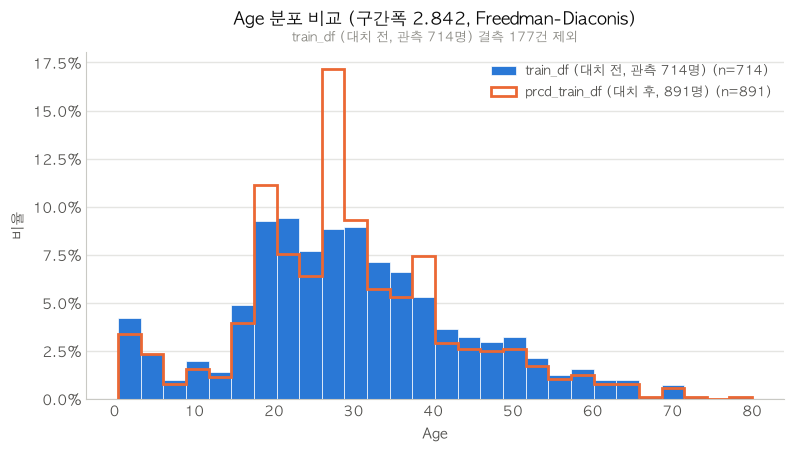

n 결측    평균  표준편차    최소    Q1   중앙값    Q3    최대   IQR
기준 변수  그룹                                                            
전체     -       891  0  29.1  13.5   0.4  21.0  26.0  36.8  80.0  15.8
hasAge 0       177  0  26.9   7.7   4.0  26.0  26.0  31.0  48.5   5.0
       1       714  0  29.7  14.5   0.4  20.1  28.0  38.0  80.0  17.9
Title  Master   40  0   4.5   3.4   0.4   1.8   4.0   7.2  12.0   5.5
       Miss    185  0  21.2  11.7   0.8  16.0  18.0  27.0  63.0  11.0
       Mr      517  0  31.5  11.5  11.0  25.0  28.0  37.0  80.0  12.0
       Mrs     126  0  35.7  10.8  14.0  28.2  35.0  42.0  63.0  13.8
       기타       23  0  45.7  11.5  23.0  39.0  48.5  53.0  70.0  14.0

,행 수,Age 결측,hasAge=1 비율,hasCabin=1 비율,Deck 범주 수,Deck=Unknown 비율
prcd_train_df,891,0,80.1%,22.9%,9,77.1%
prcd_test_df,418,0,79.4%,21.8%,8,78.2%


prcd_train_df         prcd_test_df        
                         도수    상대도수           도수    상대도수
Deck 계급 (범주형)                                           
A                        15    1.7%            7    1.7%
B                        47    5.3%           18    4.3%
C                        59    6.6%           35    8.4%
D                        33    3.7%           13    3.1%
E                        32    3.6%            9    2.2%
F                        13    1.5%            8    1.9%
G                         4    0.4%            1    0.2%
T                         1    0.1%            0    0.0%
Unknown                 687   77.1%          327   78.2%
합계                      891  100.0%          418  100.0%

,train_df (대치 전),prcd_train_df (대치 후)
Embarked,,
C,168,168
Q,77,77
S,644,646
결측(NaN),2,0


,Pclass,SibSp,Parch,Embarked,Fare
PassengerId,,,,,
1044,3,0,0,S,7.8958


원본 유지 확인: train_df Age 결측 177건 · Embarked 결측 2건, test_df Fare 결측 1건 (모두 대치 전 그대로)
대치본에 남은 결측 컬럼: {'prcd_train_df': ['Cabin'], 'prcd_test_df': ['Cabin']}
- Cabin, Side: 파생 재료로만 쓰는 EDA용 원본 컬럼이라 채우지 않는다 (모델에는 hasCabin·Deck만 넣는다).


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Deck,Side,hasAge,hasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Unknown,Missing,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,C,Starboard,1,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Unknown,Missing,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,C,Starboard,1,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Unknown,Missing,1,0


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Deck,Side,hasAge,hasCabin
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,Unknown,Missing,1,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,Unknown,Missing,1,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,Unknown,Missing,1,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,Unknown,Missing,1,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,Unknown,Missing,1,0


In [423]:
# 대처 결과 확인

print("prcd_train_df 결측 현황")
display(get_nullcnt_ratio_describe(prcd_train_df))
print("")
print("prcd_test_df 결측 현황")
display(get_nullcnt_ratio_describe(prcd_test_df))

# 1. 대치로 인해 분포가 얼마나 바뀌었는 지 확인한다. 
compare_histograms({"train_df (대치 전, 관측 714명)": train_df, "prcd_train_df (대치 후, 891명)": prcd_train_df}, "Age")
plt.show()

# 2. 대치된 행과 원래 관측된 행의 Age 기술통계 비교 (hasAge=0이 대치된 행)
display(group_stats_table(prcd_train_df, "Age", ["hasAge", "Title"]))

# 3. 새로 만든 파생 피처 확인
summary = pd.DataFrame({
    name: {
        "행 수": len(df),
        "Age 결측": int(df["Age"].isna().sum()),
        "hasAge=1 비율": df["hasAge"].mean(),
        "hasCabin=1 비율": df["hasCabin"].mean(),
        "Deck 범주 수": df["Deck"].nunique(),
        "Deck=Unknown 비율": df["Deck"].eq("Unknown").mean(),
    }
    for name, df in (("prcd_train_df", prcd_train_df), ("prcd_test_df", prcd_test_df))
}).transpose()
display(format_table(summary, {"비율": "{:.1%}"}))
display(frequency_table({"prcd_train_df": prcd_train_df, "prcd_test_df": prcd_test_df}, "Deck"))

# 4. 소수 결측(Embarked 2건, Fare 1건)이 어떻게 채워졌는지 확인
label_na = lambda counts: counts.rename(index=lambda v: "결측(NaN)" if pd.isna(v) else v)
display(pd.DataFrame({
    "train_df (대치 전)": label_na(train_df["Embarked"].value_counts(dropna=False)),
    "prcd_train_df (대치 후)": label_na(prcd_train_df["Embarked"].value_counts(dropna=False)),
}).fillna(0).astype(int).rename_axis("Embarked"))

filled_fare = prcd_test_df.loc[test_df["Fare"].isna(), ["PassengerId", "Pclass", "SibSp", "Parch", "Embarked", "Fare"]]
display(filled_fare.set_index("PassengerId"))

# 5. 원본이 그대로 남아 있는지, 대치본에 남은 결측이 무엇인지 확인
print(f"원본 유지 확인: train_df Age 결측 {train_df['Age'].isna().sum()}건 · Embarked 결측 {train_df['Embarked'].isna().sum()}건, "
      f"test_df Fare 결측 {test_df['Fare'].isna().sum()}건 (모두 대치 전 그대로)")

remaining = {name: df.columns[df.isna().any()].tolist()
             for name, df in (("prcd_train_df", prcd_train_df), ("prcd_test_df", prcd_test_df))}
print(f"대치본에 남은 결측 컬럼: {remaining}")
print("- Cabin, Side: 파생 재료로만 쓰는 EDA용 원본 컬럼이라 채우지 않는다 (모델에는 hasCabin·Deck만 넣는다).")

display(prcd_train_df.head(5))
display(prcd_test_df.head(5))

### 4. 타깃(Survived)과 피처의 관계